<a href="https://colab.research.google.com/github/NirmalaBhushal/malicious-url-failure-analysis/blob/main/Research3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step:1 Dataset Acquisition

In [ ]:
!pip install -q scikit-learn tensorflow shap lime tldextract python-whois dnspython requests pandas numpy matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 1 — DATASET ACQUISITION
# ============================================================
# PURPOSE
#   Pull real phishing / malware / benign URLs from live public feeds
#   (PhishTank, URLHaus, OpenPhish, Tranco). Synthetic placeholder URLs
#   are allowed only as a top-up for phishing/malware.
#
# REQUIRES
#   - tranco_38Z2L.csv (or your Tranco filename) uploaded to the
#     Colab working directory before running (sidebar > Files > upload)
#
# PRODUCES
#   - frozen_dataset.csv  (raw acquired dataset, all real+top-up rows)
#
# NEXT STEP
#   step1b_balance_dataset.py
# ============================================================

# ------------------------------------------------------------
# Install dependencies
# ------------------------------------------------------------
# !pip install -q scikit-learn tensorflow shap lime tldextract python-whois dnspython requests pandas numpy matplotlib

import os
import csv
import requests
import random
import pandas as pd

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# ----------------------------------------------------------------------
# Real data sources
# ----------------------------------------------------------------------

def fetch_phishtank_sample(limit=50000):
    """No API key needed — PhishTank's registration is currently disabled,
    so this uses their public CSV feed with a descriptive User-Agent instead."""
    try:
        headers = {"User-Agent": "phishtank/research-project"}
        r = requests.get("http://data.phishtank.com/data/online-valid.csv", timeout=30, headers=headers)
        r.raise_for_status()
        lines = r.text.splitlines()
        reader = csv.DictReader(lines)
        urls = []
        for row in reader:
            if row.get("url"):
                urls.append(row["url"])
            if len(urls) >= limit:
                break
        return pd.DataFrame({"url": urls, "label": "phishing", "source": "phishtank_real"}) if urls else None
    except Exception as e:
        print("PhishTank failed:", e)
        return None


def fetch_urlhaus_sample(limit=50000):
    """Public CSV feed — no API key required (the newer v1 JSON API needs one)."""
    try:
        r = requests.get("https://urlhaus.abuse.ch/downloads/csv_recent/", timeout=20)
        r.raise_for_status()
        lines = [l for l in r.text.splitlines() if l and not l.startswith("#")]
        reader = csv.reader(lines)
        urls = []
        for row in reader:
            if len(row) > 2:
                urls.append(row[2].strip('"'))
            if len(urls) >= limit:
                break
        return pd.DataFrame({"url": urls, "label": "malware", "source": "urlhaus_real"}) if urls else None
    except Exception as e:
        print("URLHaus failed:", e)
        return None


def fetch_openphish_sample(limit=50000):
    """Public rolling feed of ~500 URLs, no key required."""
    try:
        r = requests.get("https://openphish.com/feed.txt", timeout=15)
        r.raise_for_status()
        urls = r.text.strip().split("\n")[:limit]
        return pd.DataFrame({"url": urls, "label": "phishing", "source": "openphish_real"})
    except Exception as e:
        print("OpenPhish failed:", e)
        return None


def fetch_tranco_sample(limit=50000, filename="tranco_38Z2L.csv"):
    """Loads your manually uploaded Tranco list.

    FIX: this used to catch FileNotFoundError and return None, which let the
    pipeline silently fall back to ~300 synthetic benign URLs with no real
    domains behind them. That corrupted every downstream WHOIS/redirect
    feature for the benign class. It now raises instead, so a missing file
    stops the run immediately with a clear message.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"'{filename}' not found in the working directory.\n"
            f"Upload the Tranco CSV to Colab (left sidebar > Files > upload) "
            f"before running Step 1. The pipeline will NOT proceed on "
            f"synthetic-only benign data."
        )
    df = pd.read_csv(filename, names=["rank", "domain"], header=None)
    urls = ["http://" + d for d in df["domain"].head(limit)]
    return pd.DataFrame({"url": urls, "label": "benign", "source": "tranco_real"})


# ----------------------------------------------------------------------
# Synthetic fallback — ONLY for phishing/malware top-ups.
# Benign is deliberately excluded: synthetic benign URLs are random
# strings pointing at domains that don't exist, so WHOIS/redirect lookups

# ----------------------------------------------------------------------

def build_synthetic_sample(n_per_class=150, only_labels=None):
    rng = random.Random(RANDOM_SEED)
    phishing_tlds = [".top", ".xyz", ".cf", ".gq", ".tk"]
    shorteners = ["bit.ly", "tinyurl.com", "t.co"]

    def tok(k):
        return "".join(rng.choice("abcdefghijklmnopqrstuvwxyz0123456789-") for _ in range(k))

    labels = only_labels or ["phishing", "malware"]
    if "benign" in labels:
        raise ValueError(
            "Refusing to synthesize benign URLs — synthetic benign data "
            "silently corrupts WHOIS/redirect features downstream. "
            "Fix fetch_tranco_sample() instead of topping up benign here."
        )

    rows = []
    if "phishing" in labels:
        for _ in range(n_per_class):
            rows.append({
                "url": f"http://{tok(rng.randint(6, 14))}{rng.choice(phishing_tlds)}/{tok(8)}?login=verify",
                "label": "phishing", "source": "synthetic"
            })
        for _ in range(n_per_class // 2):
            rows.append({
                "url": f"http://{rng.choice(shorteners)}/{tok(6)}",
                "label": "phishing", "source": "synthetic"
            })
    if "malware" in labels:
        for _ in range(n_per_class):
            rows.append({
                "url": f"http://{tok(rng.randint(5, 10))}{rng.choice(phishing_tlds)}/index.php?id={rng.randint(1, 999)}",
                "label": "malware", "source": "synthetic"
            })
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------
# Pull everything together
# ----------------------------------------------------------------------

frames = [f() for f in (fetch_phishtank_sample, fetch_urlhaus_sample, fetch_openphish_sample, fetch_tranco_sample)]
frames = [f for f in frames if f is not None]
raw_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["url", "label", "source"])

MIN_PER_CLASS = 100
counts = raw_df["label"].value_counts().to_dict() if len(raw_df) else {}

# Only phishing/malware are eligible for synthetic top-up now
thin_attack_classes = [lbl for lbl in ["phishing", "malware"] if counts.get(lbl, 0) < MIN_PER_CLASS]

if thin_attack_classes:
    print(f"Topping up under-represented attack classes with synthetic data: {thin_attack_classes}")
    synth = build_synthetic_sample(n_per_class=150, only_labels=thin_attack_classes)
    raw_df = pd.concat([raw_df, synth], ignore_index=True)

raw_df = raw_df.drop_duplicates(subset="url").reset_index(drop=True)
raw_df["url_id"] = raw_df.index.astype(str)

# ----------------------------------------------------------------------
# Provenance check —
# ----------------------------------------------------------------------
print("Counts by label:")
print(raw_df["label"].value_counts())
print("\nCounts by source (real feed vs synthetic):")
print(raw_df["source"].value_counts())
print("\nCounts by label AND source:")
print(raw_df.groupby(["label", "source"]).size())

MIN_REAL_BENIGN = 5000  # tune this to  target benign sample size
real_benign_count = len(raw_df[(raw_df["label"] == "benign") & (raw_df["source"] != "synthetic")])

assert real_benign_count >= MIN_REAL_BENIGN, (
    f"\n\nONLY {real_benign_count} REAL benign URLs loaded (need >= {MIN_REAL_BENIGN}).\n"
    f"Check that the Tranco CSV actually loaded (see FileNotFoundError above if it didn't).\n"
    f"Do NOT proceed with a synthetic-dominated benign class — it silently "
    f"corrupts feature extraction (WHOIS/redirect lookups on non-existent domains)."
)

print(f"\nPASSED: {real_benign_count} real benign URLs confirmed.")

raw_df.to_csv("frozen_dataset.csv", index=False)

print(f"\nFrozen dataset saved with {len(raw_df)} URLs")

FileNotFoundError: 'tranco_38Z2L.csv' not found in the working directory.
Upload the Tranco CSV to Colab (left sidebar > Files > upload) before running Step 1. The pipeline will NOT proceed on synthetic-only benign data.

#Step :1b Balance Dataset

In [ ]:
# ============================================================
# STEP 1b — BALANCE CLASSES (~15K PER CLASS, DOMAIN-DIVERSITY AWARE)
# ============================================================
# PURPOSE
#   The raw dataset from Step 1 is class-imbalanced (e.g. 50k phishing
#   vs. 15k malware). A naive random downsample would also silently
#   bias toward whichever domains happen to have the most repeated
#   URLs. This dedupes to one row per domain FIRST, then tops up from
#   remaining rows only if a class doesn't have enough unique domains
#   to hit the target — so row-count balance doesn't come at the cost
#   of domain diversity.
#
# REQUIRES
#   - frozen_dataset.csv (from Step 1)
#
# PRODUCES
#   - balanced_dataset.csv  (~TARGET_PER_CLASS rows per class)
#
# NEXT STEP
#   step1c_snapshot_features.py
# ============================================================

import pandas as pd
import tldextract

RANDOM_SEED = 42
TARGET_PER_CLASS = 15000

raw_df = pd.read_csv("frozen_dataset.csv")

print("Before balancing:")
print(raw_df["label"].value_counts())

# ------------------------------------------------------------
# Lightweight domain extraction (full normalization happens in Step 2 —
# this is just enough to dedupe for sampling purposes)
# ------------------------------------------------------------
def get_domain(url):
    try:
        ext = tldextract.extract(str(url))
        return f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain
    except Exception:
        return str(url)

raw_df["_domain"] = raw_df["url"].apply(get_domain)


def balanced_sample(df_label, target, label_name):
    n_available = len(df_label)
    n_domains = df_label["_domain"].nunique()

    if n_available <= target:
        print(f"{label_name}: only {n_available} rows available (<= target {target}), keeping all")
        return df_label

    # Shuffle once for reproducibility
    shuffled = df_label.sample(frac=1, random_state=RANDOM_SEED)

    # First pass: one row per unique domain, up to target
    one_per_domain = shuffled.drop_duplicates(subset="_domain", keep="first")
    print(f"{label_name}: {n_available} rows across {n_domains} unique domains")

    if len(one_per_domain) >= target:
        result = one_per_domain.sample(n=target, random_state=RANDOM_SEED)
        print(f"  -> sampled {target} rows, each from a distinct domain")
        return result

    # Not enough unique domains to hit target with 1-per-domain alone —
    # take all unique-domain rows, then top up with extra rows from
    # domains already included (keeps some multi-path signal without
    # letting a single domain dominate arbitrarily)
    remaining_needed = target - len(one_per_domain)
    leftover_pool = shuffled.drop(one_per_domain.index)
    topup = leftover_pool.sample(n=min(remaining_needed, len(leftover_pool)), random_state=RANDOM_SEED)
    result = pd.concat([one_per_domain, topup], ignore_index=False)
    print(f"  -> only {n_domains} unique domains available; took all of them "
          f"+ {len(topup)} extra rows to reach {len(result)} total")
    return result


balanced_frames = []
for label in sorted(raw_df["label"].unique()):
    subset = raw_df[raw_df["label"] == label]
    balanced_frames.append(balanced_sample(subset, TARGET_PER_CLASS, label))

balanced_df = pd.concat(balanced_frames, ignore_index=True).drop(columns=["_domain"])
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)  # shuffle rows

print("\nAfter balancing:")
print(balanced_df["label"].value_counts())
print("\nBy label and source:")
print(balanced_df.groupby(["label", "source"]).size())

balanced_df.to_csv("balanced_dataset.csv", index=False)
print(f"\nSaved balanced_dataset.csv with {len(balanced_df)} URLs")
print("Point Step 2's FROZEN_DATASET variable at 'balanced_dataset.csv' to use this.")

Before balancing:
label
phishing    50291
benign      50000
malware     15570
Name: count, dtype: int64
benign: 50000 rows across 35557 unique domains
  -> sampled 15000 rows, each from a distinct domain
malware: 15570 rows across 5172 unique domains
  -> only 5172 unique domains available; took all of them + 9828 extra rows to reach 15000 total
phishing: 50291 rows across 12448 unique domains
  -> only 12448 unique domains available; took all of them + 2552 extra rows to reach 15000 total

After balancing:
label
phishing    15000
benign      15000
malware     15000
Name: count, dtype: int64

By label and source:
label     source        
benign    tranco_real       15000
malware   urlhaus_real      15000
phishing  openphish_real      113
          phishtank_real    14887
dtype: int64

Saved balanced_dataset.csv with 45000 URLs
Point Step 2's FROZEN_DATASET variable at 'balanced_dataset.csv' to use this.


#STEP :1c snapshot features

In [ ]:
# ============================================================
# STEP 1c — IMMEDIATE FEATURE SNAPSHOT (WHOIS/RDAP + REDIRECT TRACE)
# ============================================================
# PURPOSE
#   Capture WHOIS/RDAP registrar+creation-date and live redirect chains
#   for every balanced URL IMMEDIATELY after Step 1b — same session, no
#   delay. This is what makes the methodology's "pre-saved historical
#   snapshot, not live re-crawling" claim literally true: infrastructure
#   is captured close to ingestion time, before fast-turnover phishing
#   sites (median ~5.46hr lifespan) have a chance to go offline.
#
#   Also skips network calls entirely for raw-IP-hosted URLs (common
#   for malware) and uses RDAP (HTTP+JSON, clean timeouts) instead of
#   legacy WHOIS (blocking sockets, prone to runaway background threads)
#   for speed and reliability.
#
# REQUIRES
#   - balanced_dataset.csv (from Step 1b)
#   - Run in the SAME session as Step 1b, immediately after — that
#     immediacy is the entire point of this step
#
# PRODUCES
#   - snapshotted_dataset.csv  (balanced URLs + host/registrar/
#     domain_age/redirect data, each row timestamped)
#   - whois_cache.db  (persistent disk cache, reused across reruns)
#
# NEXT STEP
#   step2_load_and_split.py
# ============================================================

import os
import time
import ipaddress
import sqlite3
import concurrent.futures
import concurrent.futures.thread
import threading
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import re
import tldextract
import requests

RDAP_WORKERS = 25          # spread across many registries now, so this can stay lower and still be fast
RDAP_TIMEOUT = 3
REDIRECT_MAX_HOPS = 3      # not the speed-capped value — this runs once, immediately, so it's
REDIRECT_TIMEOUT = 2       # worth spending a bit more here to capture real redirect chains
SHORTENERS = {"bit.ly", "tinyurl.com", "t.co", "goo.gl", "ow.ly", "is.gd"}

SNAPSHOT_TIMESTAMP = datetime.now(timezone.utc).isoformat()
print(f"Snapshot started at: {SNAPSHOT_TIMESTAMP}")

# ------------------------------------------------------------
# Load balanced dataset
# ------------------------------------------------------------
if not os.path.exists("balanced_dataset.csv"):
    raise FileNotFoundError("balanced_dataset.csv not found — run step1b first.")

raw_df = pd.read_csv("balanced_dataset.csv")
print(f"Snapshotting {len(raw_df)} URLs")

# ------------------------------------------------------------
# URL normalisation — includes the fixed registered_domain calc
# (avoids the earlier bug where IP-hosted URLs collapsed into a
# shared group key)
# ------------------------------------------------------------
def normalize_url(url):
    url = str(url)
    if not re.match(r'^[a-zA-Z]+://', url):
        url = "http://" + url
    ext = tldextract.extract(url)
    host = ".".join(p for p in [ext.subdomain, ext.domain, ext.suffix] if p)
    if ext.suffix:
        registered_domain = f"{ext.domain}.{ext.suffix}"
    else:
        registered_domain = ext.domain or host
    return {
        "normalized_url": url,
        "host": host,
        "registered_domain": registered_domain,
        "tld": ext.suffix,
    }

norm = raw_df["url"].apply(normalize_url).apply(pd.Series)
df = pd.concat([raw_df, norm], axis=1)

def is_ip_host(host):
    try:
        ipaddress.ip_address(host)
        return True
    except ValueError:
        return False

# ------------------------------------------------------------
# PERSISTENT disk-backed host cache
# ------------------------------------------------------------
whois_conn = sqlite3.connect("whois_cache.db", check_same_thread=False)
whois_conn.execute("""
CREATE TABLE IF NOT EXISTS whois_cache (
    host TEXT PRIMARY KEY,
    registrar TEXT,
    creation_date TEXT,
    lookup_method TEXT,
    fetched_at TEXT
)
""")
whois_conn.commit()


_cache_write_lock = threading.Lock()

def _load_whois_cache():
    rows = whois_conn.execute("SELECT host, registrar, creation_date FROM whois_cache").fetchall()
    return {h: {"registrar": r, "_creation_date": c} for h, r, c in rows}

_whois_cache = _load_whois_cache()
print(f"Loaded {len(_whois_cache)} cached host lookups from disk.")

def _write_cache(host, registrar, creation_date, method):
    with _cache_write_lock:
        whois_conn.execute(
            "INSERT OR REPLACE INTO whois_cache VALUES (?,?,?,?,?)",
            (host, registrar, str(creation_date) if creation_date else None, method,
             datetime.now(timezone.utc).isoformat())
        )
        whois_conn.commit()

RDAP_BOOTSTRAP_FALLBACK = "https://rdap.org/domain/{}"
RDAP_BOOTSTRAP_REGISTRY_URL = "https://data.iana.org/rdap/dns.json"

def load_rdap_bootstrap_map(session):
    """Fetch IANA's TLD -> RDAP registry mapping ONCE, so lookups go
    directly to the authoritative registry (Verisign, PIR, etc.) instead
    of funneling all 34k+ requests through the shared rdap.org
    redirector, which starts throttling after a few thousand requests
    in a short window. Falls back to rdap.org per-host if this fails
    or a TLD isn't listed."""
    tld_map = {}
    try:
        with session.get(RDAP_BOOTSTRAP_REGISTRY_URL, timeout=10) as r:
            r.raise_for_status()
            data = r.json()
        for entry in data.get("services", []):
            tlds, base_urls = entry[0], entry[1]
            if not base_urls:
                continue
            base_url = base_urls[0].rstrip("/") + "/"
            for tld in tlds:
                tld_map[tld.lower()] = base_url
        print(f"Loaded RDAP bootstrap map: {len(tld_map)} TLDs -> direct registry endpoints")
    except Exception as e:
        print(f"Could not load RDAP bootstrap map ({e}) — falling back to rdap.org for all lookups")
    return tld_map

_bootstrap_session = requests.Session()
RDAP_TLD_MAP = load_rdap_bootstrap_map(_bootstrap_session)

def rdap_lookup(host, session, timeout=RDAP_TIMEOUT):
    # Prefer the authoritative registry's own RDAP endpoint (fast, no
    # shared-service rate limit). Only fall back to rdap.org for TLDs
    # not in the bootstrap map — a small minority.
    top_level = host.rsplit(".", 1)[-1].lower()
    base_url = RDAP_TLD_MAP.get(top_level)
    rdap_url = f"{base_url}domain/{host}" if base_url else RDAP_BOOTSTRAP_FALLBACK.format(host)
    try:
        with session.get(rdap_url, timeout=timeout) as r:
            if r.status_code != 200:
                return None
            data = r.json()
        registrar = "unknown"
        for entity in data.get("entities", []):
            if "registrar" in entity.get("roles", []):
                vcard = entity.get("vcardArray")
                if vcard and len(vcard) > 1:
                    for field in vcard[1]:
                        if field[0] == "fn":
                            registrar = field[3]
                            break
                break
        creation_date = None
        for event in data.get("events", []):
            if event.get("eventAction") == "registration":
                creation_date = event.get("eventDate")
                break
        return {"registrar": registrar, "_creation_date": creation_date}
    except Exception:
        return None

def fetch_host_info(host, session):
    if host in _whois_cache:
        return _whois_cache[host]
    if is_ip_host(host):
        result = {"registrar": "ip_address", "_creation_date": None}
        _whois_cache[host] = result
        _write_cache(host, "ip_address", None, "skipped_ip")
        return result
    rdap_result = rdap_lookup(host, session)
    if rdap_result is not None:
        _whois_cache[host] = rdap_result
        _write_cache(host, rdap_result["registrar"], rdap_result["_creation_date"], "rdap")
        return rdap_result
    result = {"registrar": "unknown", "_creation_date": None}
    _whois_cache[host] = result
    _write_cache(host, "unknown", None, "rdap_failed")
    return result

def extract_behavioural_features(url, host, session):
    is_shortener = int(any(s in host for s in SHORTENERS))
    hops, current = 0, url
    try:
        for _ in range(REDIRECT_MAX_HOPS):

            with session.get(current, timeout=REDIRECT_TIMEOUT, allow_redirects=False) as resp:
                if resp.status_code in (301, 302, 303, 307, 308) and "Location" in resp.headers:
                    hops += 1
                    current = requests.compat.urljoin(current, resp.headers["Location"])
                else:
                    break
    except Exception:
        pass
    return {"redirect_hops": hops, "is_shortener": is_shortener}

def extract_temporal_features(creation_date, reference_date=None):
    reference_date = reference_date or datetime.now(timezone.utc)
    if creation_date is None:
        return {"domain_age_days": -1}
    if isinstance(creation_date, str):
        try:
            creation_date = datetime.fromisoformat(creation_date.replace("Z", "+00:00"))
        except Exception:
            return {"domain_age_days": -1}
    try:
        if creation_date.tzinfo is None:
            creation_date = creation_date.replace(tzinfo=timezone.utc)
        return {"domain_age_days": (reference_date - creation_date).days}
    except Exception:
        return {"domain_age_days": -1}

# ============================================================
# 1) RDAP FAN-OUT — deduped by host
# ============================================================
unique_hosts = df["host"].dropna().unique()
uncached_hosts = [h for h in unique_hosts if h not in _whois_cache]
print(f"Unique hosts: {len(unique_hosts)} | cached: {len(unique_hosts)-len(uncached_hosts)} "
      f"| to fetch: {len(uncached_hosts)}")

thread_local = threading.local()
def _get_session():
    if not hasattr(thread_local, "session"):
        session = requests.Session()
        # FIX: default pool_maxsize=10 per host was getting exhausted —
        # responses weren't being explicitly closed (see below), so
        # connections sat "checked out" until garbage collection caught
        # up. That backlog grew over the run, forcing more and more
        # requests to pay a fresh TCP/TLS handshake instead of reusing
        # a pooled connection — this is why the ETA kept climbing.
        # Enlarging the pool gives headroom while the explicit close()
        # calls below fix the actual leak.
        adapter = requests.adapters.HTTPAdapter(pool_connections=50, pool_maxsize=50)
        session.mount("http://", adapter)
        session.mount("https://", adapter)
        thread_local.session = session
    return thread_local.session

RDAP_MAX_MINUTES = 6

if uncached_hosts:
    executor = concurrent.futures.ThreadPoolExecutor(max_workers=RDAP_WORKERS)
    futures = {executor.submit(fetch_host_info, h, _get_session()): h for h in uncached_hosts}
    done, errors, start = 0, 0, time.time()
    deadline = start + RDAP_MAX_MINUTES * 60

    for future in concurrent.futures.as_completed(futures):

        try:
            future.result()
        except Exception as e:
            errors += 1
            if errors <= 5:  # don't flood the log, just show the first few
                print(f"  [error] host lookup failed: {e}")

        done += 1
        if done % 500 == 0:
            elapsed = time.time() - start
            rate = done / elapsed
            eta_min = (len(uncached_hosts) - done) / rate / 60 if rate > 0 else float("inf")
            print(f"  RDAP {done}/{len(uncached_hosts)} ({elapsed:.0f}s, ~{eta_min:.0f} min remaining, "
                  f"{errors} errors so far)")

        if time.time() > deadline:
            print(f"\nHit the {RDAP_MAX_MINUTES}-minute ceiling after {done}/{len(uncached_hosts)} hosts — "
                  f"stopping here. Remaining hosts stay registrar='unknown', domain_age_days=-1.")
            break

    executor.shutdown(wait=False)
    print(f"\nTotal errors during RDAP fan-out: {errors}")
    if errors > len(uncached_hosts) * 0.3:
        print("WARNING: error rate is high (>30%) — check the sample errors printed above; "
              "something may be systematically failing (bad TLD map, network issue, etc.)")
print("RDAP fan-out complete.")

# ============================================================
# 2) BEHAVIORAL (redirect) SNAPSHOT — per URL, immediate
# ============================================================
def snapshot_row(row, session):
    host_feats = _whois_cache.get(row["host"], {"registrar": "unknown", "_creation_date": None})
    behav_feats = extract_behavioural_features(row["normalized_url"], row["host"], session)
    temporal_feats = extract_temporal_features(host_feats.get("_creation_date"))
    return {
        "url_id": row["url_id"],
        "registrar": host_feats.get("registrar", "unknown"),
        "redirect_hops": behav_feats["redirect_hops"],
        "is_shortener": behav_feats["is_shortener"],
        "domain_age_days": temporal_feats["domain_age_days"],
        "hosting_country": "unknown",
        "snapshot_timestamp": SNAPSHOT_TIMESTAMP,
    }

rows = df.to_dict("records")
results = []
start = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=30) as executor:
    futures = {executor.submit(snapshot_row, row, _get_session()): row for row in rows}
    done_count = 0
    for future in concurrent.futures.as_completed(futures):
        try:
            results.append(future.result())
        except Exception:
            row = futures[future]
            results.append({"url_id": row["url_id"]})
        done_count += 1
        if done_count % 1000 == 0:
            elapsed = time.time() - start
            rate = done_count / elapsed
            eta_min = (len(rows) - done_count) / rate / 60 if rate > 0 else float("inf")
            print(f"  Snapshot {done_count}/{len(rows)} ({elapsed:.0f}s, ~{eta_min:.0f} min remaining)")

snapshot_df = pd.DataFrame(results)
full_snapshot = df.merge(snapshot_df, on="url_id")
full_snapshot.to_csv("snapshotted_dataset.csv", index=False)

print(f"\nSnapshot complete in {time.time()-start:.0f}s.")
print(f"Saved snapshotted_dataset.csv with {len(full_snapshot)} rows, timestamp={SNAPSHOT_TIMESTAMP}")

print("\nShare of domain_age_days == -1 (unresolved) by label:")
print(full_snapshot.groupby("label")["domain_age_days"].apply(lambda s: (s == -1).mean()).round(3))
print("\nRegistrar 'ip_address' share by label:")
print(full_snapshot.groupby("label")["registrar"].apply(lambda s: (s == "ip_address").mean()).round(3))

Snapshot started at: 2026-08-31T14:04:06.560419+00:00
Snapshotting 45000 URLs
Loaded 1 cached host lookups from disk.
Loaded RDAP bootstrap map: 1200 TLDs -> direct registry endpoints
Unique hosts: 34218 | cached: 14 | to fetch: 34204
  RDAP 500/34204 (14s, ~15 min remaining, 0 errors so far)
  RDAP 1000/34204 (30s, ~17 min remaining, 0 errors so far)
  RDAP 1500/34204 (45s, ~16 min remaining, 0 errors so far)
  RDAP 2000/34204 (62s, ~17 min remaining, 0 errors so far)
  RDAP 2500/34204 (81s, ~17 min remaining, 0 errors so far)
  RDAP 3000/34204 (99s, ~17 min remaining, 0 errors so far)
  RDAP 3500/34204 (114s, ~17 min remaining, 0 errors so far)
  RDAP 4000/34204 (128s, ~16 min remaining, 0 errors so far)
  RDAP 4500/34204 (142s, ~16 min remaining, 0 errors so far)
  RDAP 5000/34204 (161s, ~16 min remaining, 0 errors so far)
  RDAP 5500/34204 (175s, ~15 min remaining, 0 errors so far)
  RDAP 6000/34204 (188s, ~15 min remaining, 0 errors so far)
  RDAP 6500/34204 (201s, ~14 min remaini

#Step: 2 Split and Load

In [ ]:
# ============================================================
# STEP 2 — LOAD SNAPSHOT, VERIFY LABELS, DOMAIN-GROUPED SPLIT
# ============================================================
# PURPOSE
#   Load the already-snapshotted dataset (NO network calls here — all
#   WHOIS/redirect data was captured in Step 1c). Simulate a QA/label-
#   verification pass, then split into train/holdout GROUPED BY
#   REGISTERED DOMAIN, so no domain's URLs leak across both splits.
#   Reports domain diversity per class/split, since row-count balance
#   (from Step 1b) does not guarantee domain-count balance — a class
#   with few unique domains has less real feature diversity than its
#   row count suggests, because host-based features repeat within a
#   domain.
#
# REQUIRES
#   - snapshotted_dataset.csv (from Step 1c)
#
# PRODUCES (in-memory, used by later steps)
#   - train_df, holdout_df, train_balanced
#
# NEXT STEP
#   step3_lexical_features.py
# ============================================================

import os
import random
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

SNAPSHOT_FILE = "snapshotted_dataset.csv"
if not os.path.exists(SNAPSHOT_FILE):
    raise FileNotFoundError(f"{SNAPSHOT_FILE} not found. Run step1c_snapshot_features.py first.")

df = pd.read_csv(SNAPSHOT_FILE)
print(f"Loaded snapshotted dataset: {len(df)} URLs")
print(df["label"].value_counts())
print(f"\nSnapshot timestamp(s) present: {df['snapshot_timestamp'].nunique()} unique run(s)")

# ------------------------------------------------------------
# Simulated verification (same as before)
# ------------------------------------------------------------
def verify_label(row, disagreement_rate=0.03):
    rng = random.Random(hash(str(row["url_id"])) ^ RANDOM_SEED)
    return "flagged" if rng.random() < disagreement_rate else "verified"

df["label_status"] = df.apply(verify_label, axis=1)
print(f'\n{(df["label_status"]=="flagged").sum()} records flagged for review')

df_clean = df[df["label_status"] == "verified"].reset_index(drop=True)

# ------------------------------------------------------------
# Domain-grouped train/holdout split
# ------------------------------------------------------------
df_clean["group_key"] = df_clean["registered_domain"].fillna(df_clean["host"])

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, holdout_idx = next(gss.split(df_clean, groups=df_clean["group_key"]))

train_df = df_clean.iloc[train_idx].reset_index(drop=True)
holdout_df = df_clean.iloc[holdout_idx].reset_index(drop=True)

print("\nTRAIN DISTRIBUTION")
print(train_df["label"].value_counts())
print("\nHOLDOUT DISTRIBUTION")
print(holdout_df["label"].value_counts())

train_balanced = train_df.copy()
print("\nUSING FULL TRAINING SET")
print(train_balanced["label"].value_counts())

counts = train_balanced["label"].value_counts()
if counts.min() < 20:
    print(f"\nWARNING: one class has very few samples ({counts.min()}).")

# ------------------------------------------------------------
# DOMAIN DIVERSITY
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("DOMAIN DIVERSITY BY CLASS AND SPLIT")
print("=" * 60)

diversity_rows = []
for split_name, split_df in [("train", train_df), ("holdout", holdout_df)]:
    for lbl in sorted(split_df["label"].unique()):
        subset = split_df[split_df["label"] == lbl]
        n_rows = len(subset)
        n_domains = subset["registered_domain"].nunique()
        diversity_rows.append({
            "split": split_name, "label": lbl, "rows": n_rows,
            "unique_domains": n_domains,
            "rows_per_domain": round(n_rows / n_domains, 2) if n_domains else float("nan"),
        })

diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

avg_ratio = diversity_df["rows_per_domain"].mean()
high_concentration = diversity_df[diversity_df["rows_per_domain"] > avg_ratio * 1.5]
if len(high_concentration):
    print("\nNOTE: these class/split combos have notably concentrated domains:")
    print(high_concentration.to_string(index=False))

# ------------------------------------------------------------
# Sanity check: confirm raw-IP-hosted URLs (common for malware) are
# distributed across both splits, not collapsed into one
# ------------------------------------------------------------
print("\nRaw-IP-hosted URL count by split and label:")
print(df_clean[df_clean["registrar"] == "ip_address"].groupby(
    [df_clean["url_id"].isin(train_df["url_id"]).map({True: "train", False: "holdout"}), "label"]
).size())

Loaded snapshotted dataset: 45000 URLs
label
phishing    15000
benign      15000
malware     15000
Name: count, dtype: int64

Snapshot timestamp(s) present: 1 unique run(s)

1375 records flagged for review

TRAIN DISTRIBUTION
label
malware     10998
phishing    10977
benign      10942
Name: count, dtype: int64

HOLDOUT DISTRIBUTION
label
benign      3605
phishing    3563
malware     3540
Name: count, dtype: int64

USING FULL TRAINING SET
label
malware     10998
phishing    10977
benign      10942
Name: count, dtype: int64

DOMAIN DIVERSITY BY CLASS AND SPLIT
  split    label  rows  unique_domains  rows_per_domain
  train   benign 10942           10942             1.00
  train  malware 10998            3836             2.87
  train phishing 10977            9020             1.22
holdout   benign  3605            3605             1.00
holdout  malware  3540            1262             2.81
holdout phishing  3563            3058             1.17

NOTE: these class/split combos have notabl

#Step :3 lexical features

In [ ]:
# ============================================================
# STEP 3 — LEXICAL FEATURES (NO NETWORK CALLS)
# ============================================================
# PURPOSE
#   Compute string-based URL features (length, entropy, punctuation
#   counts, subdomain count) — these don't decay over time, so they're
#   safe to compute here rather than at ingestion. WHOIS/redirect data
#   was already captured in Step 1c; this step just merges everything
#   into the full_df used by Steps 4-9. Pure pandas, no network calls,
#   should run in seconds regardless of dataset size.
#
# REQUIRES
#   - train_balanced, holdout_df (from Step 2, same session)
#
# PRODUCES (in-memory, used by later steps)
#   - full_df  (all lexical + host + behavioral + temporal features)
#
# NEXT STEP
#   step4_random_forest.py
# ============================================================

import numpy as np
import pandas as pd
import tldextract

def extract_lexical_features(url):
    length = len(url)
    entropy = 0.0
    if length:
        freqs = pd.Series(list(url)).value_counts(normalize=True)
        entropy = -(freqs * np.log2(freqs)).sum()
    ext = tldextract.extract(url)
    return {
        "url_length": length,
        "char_entropy": entropy,
        "hyphen_count": url.count("-"),
        "question_count": url.count("?"),
        "dot_count": url.count("."),
        "subdomain_count": len([p for p in ext.subdomain.split(".") if p]),
    }

combined = pd.concat([train_balanced, holdout_df], ignore_index=True)
print(f"Computing lexical features for {len(combined)} URLs (no network calls)")

lexical_rows = combined["normalized_url"].apply(extract_lexical_features).apply(pd.Series)
lexical_rows["url_id"] = combined["url_id"].values

full_df = combined.merge(lexical_rows, on="url_id")

print(f"Done. Total rows: {len(full_df)}")
print("\nColumns available:", sorted(full_df.columns.tolist()))

print("\nShare of domain_age_days == -1 (unresolved) by label:")
print(full_df.groupby("label")["domain_age_days"].apply(lambda s: (s == -1).mean()).round(3))
print("\nRegistrar 'ip_address' share by label:")
print(full_df.groupby("label")["registrar"].apply(lambda s: (s == "ip_address").mean()).round(3))

full_df.head()

Computing lexical features for 43625 URLs (no network calls)
Done. Total rows: 43625

Columns available: ['char_entropy', 'domain_age_days', 'dot_count', 'group_key', 'host', 'hosting_country', 'hyphen_count', 'is_shortener', 'label', 'label_status', 'normalized_url', 'question_count', 'redirect_hops', 'registered_domain', 'registrar', 'snapshot_timestamp', 'source', 'subdomain_count', 'tld', 'url', 'url_id', 'url_length']

Share of domain_age_days == -1 (unresolved) by label:
label
benign      0.385
malware     0.976
phishing    0.711
Name: domain_age_days, dtype: float64

Registrar 'ip_address' share by label:
label
benign      0.000
malware     0.871
phishing    0.001
Name: registrar, dtype: float64


,url,label,source,url_id,normalized_url,host,registered_domain,tld,registrar,redirect_hops,...,hosting_country,snapshot_timestamp,label_status,group_key,url_length,char_entropy,hyphen_count,question_count,dot_count,subdomain_count
0,http://allegro.pl-743289.lol,phishing,phishtank_real,812,http://allegro.pl-743289.lol,allegro.pl-743289.lol,pl-743289.lol,lol,unknown,0,...,unknown,2026-08-31T14:04:06.560419+00:00,verified,pl-743289.lol,28.0,4.035582,1.0,0.0,2.0,1.0
1,https://wknmnail.weebly.com/,phishing,phishtank_real,33572,https://wknmnail.weebly.com/,wknmnail.weebly.com,weebly.com,com,unknown,0,...,unknown,2026-08-31T14:04:06.560419+00:00,verified,weebly.com,28.0,4.137538,0.0,0.0,2.0,1.0
2,http://hyros.com,benign,tranco_real,81977,http://hyros.com,hyros.com,hyros.com,com,"NameCheap, Inc.",1,...,unknown,2026-08-31T14:04:06.560419+00:00,verified,hyros.com,16.0,3.500000,0.0,0.0,1.0,0.0
3,https://qrco.de/bfoKx9,phishing,phishtank_real,45956,https://qrco.de/bfoKx9,qrco.de,qrco.de,de,unknown,0,...,unknown,2026-08-31T14:04:06.560419+00:00,verified,qrco.de,22.0,4.061482,0.0,0.0,1.0,0.0
4,http://42.235.91.77:35029/i,malware,urlhaus_real,59565,http://42.235.91.77:35029/i,42.235.91.77,42.235.91.77,NaN,ip_address,0,...,unknown,2026-08-31T14:04:06.560419+00:00,verified,42.235.91.77,27.0,3.782122,0.0,0.0,3.0,0.0


#step: 4 random forest

Registrar categories after capping: 26 (top 25 + unknown + ip_address + other_registrar)
Total feature columns after capping: 36 (was 568 before the fix)
Train class balance (is_malicious): {1: 21975, 0: 10942}
Holdout class balance (is_malicious): {1: 7103, 0: 3605}
Best CV params: {'n_estimators': 200, 'max_depth': 20} | CV accuracy: 0.967

--- Random Forest — Holdout Set ---
              precision    recall  f1-score   support

      benign       0.94      0.95      0.94      3605
   malicious       0.97      0.97      0.97      7103

    accuracy                           0.96     10708
   macro avg       0.96      0.96      0.96     10708
weighted avg       0.96      0.96      0.96     10708

[[3423  182]
 [ 217 6886]]


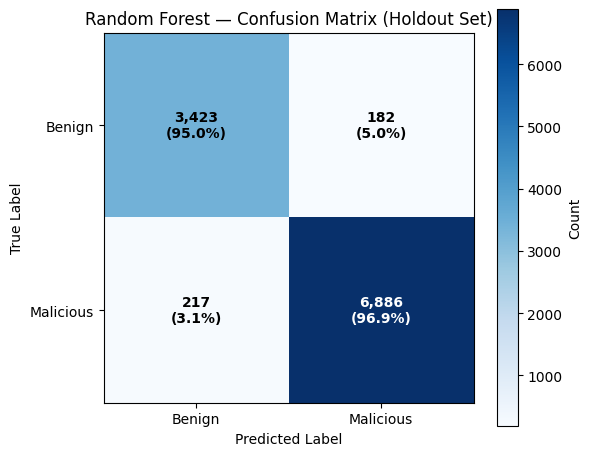

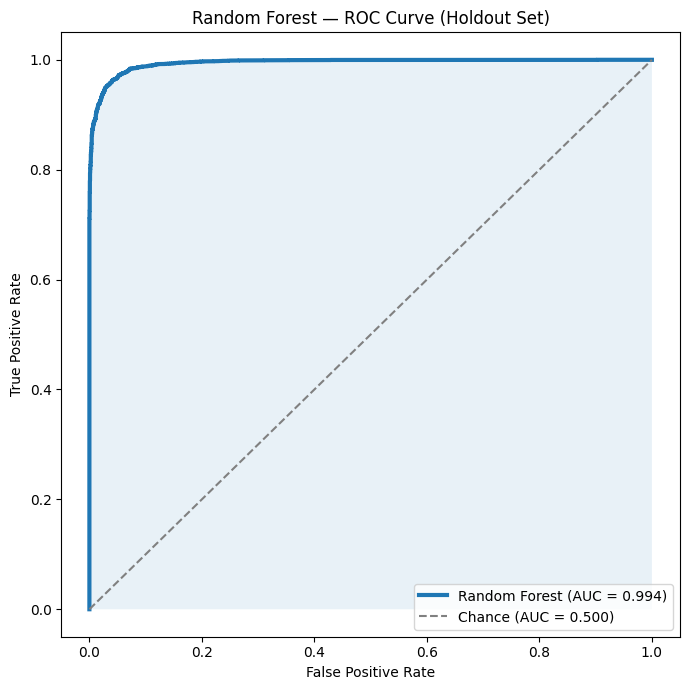


RF AUC: 0.9942


In [ ]:
# ============================================================
# STEP 4 — RANDOM FOREST: TRAIN + EVALUATE
# ============================================================
# PURPOSE
#   Train the tabular-feature baseline (Random Forest) on lexical +
#   host + behavioral + temporal features, evaluate on the domain-
#   disjoint holdout set, and save confusion matrix + ROC plots.
#   class_weight="balanced" is sufficient here since the dataset is
#   only ~2:1 (malicious:benign), not the ~190:1 of the original
#   unbalanced data.
#
# REQUIRES
#   - full_df (from Step 3)
#   - train_balanced, holdout_df (from Step 2)
#
# PRODUCES (in-memory, used by later steps)
#   - rf_model, X_train, X_holdout, y_holdout, rf_pred, rf_proba
#   - rf_holdout_mask, full_df_rf, NUMERIC_COLS, CAT_COLS
#   - rf_confusion_matrix.png, rf_roc_curve.png (saved to disk)
#
# NEXT STEP
#   step5_lstm.py
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

RANDOM_SEED = 42

full_df_rf = full_df.copy()

rf_train_mask = full_df_rf["url_id"].isin(train_balanced["url_id"])
rf_holdout_mask = full_df_rf["url_id"].isin(holdout_df["url_id"])

NUMERIC_COLS = ["url_length", "char_entropy", "hyphen_count", "question_count", "dot_count",
                "subdomain_count", "redirect_hops", "is_shortener", "domain_age_days"]
CAT_COLS = ["registrar", "hosting_country"]

full_df_rf["is_malicious"] = (full_df_rf["label"] != "benign").astype(int)

full_df_rf[CAT_COLS] = full_df_rf[CAT_COLS].fillna("unknown")


TOP_N_REGISTRARS = 25
registrar_counts = full_df_rf["registrar"].value_counts()
keep_registrars = set(registrar_counts.head(TOP_N_REGISTRARS).index) | {"unknown", "ip_address"}
full_df_rf["registrar"] = full_df_rf["registrar"].where(
    full_df_rf["registrar"].isin(keep_registrars), "other_registrar"
)
print(f"Registrar categories after capping: {full_df_rf['registrar'].nunique()} "
      f"(top {TOP_N_REGISTRARS} + unknown + ip_address + other_registrar)")

X_full_rf = pd.concat([
    full_df_rf[NUMERIC_COLS].fillna(-1),
    pd.get_dummies(full_df_rf[CAT_COLS], prefix=CAT_COLS)
], axis=1)
print(f"Total feature columns after capping: {X_full_rf.shape[1]} (was 568 before the fix)")

X_train, y_train = X_full_rf[rf_train_mask], full_df_rf.loc[rf_train_mask, "is_malicious"]
X_holdout, y_holdout = X_full_rf[rf_holdout_mask], full_df_rf.loc[rf_holdout_mask, "is_malicious"]

X_train, X_holdout = X_train.align(X_holdout, join="outer", axis=1, fill_value=0)

print("Train class balance (is_malicious):", y_train.value_counts().to_dict())
print("Holdout class balance (is_malicious):", y_holdout.value_counts().to_dict())

# ------------------------------------------------------------
# Small grid search — class_weight="balanced" is enough now that the
# dataset is roughly 2:1 (malicious:benign)
# ------------------------------------------------------------
best_score, best_params = -1, None
for n in [100, 200]:
    for d in [None, 10, 20]:
        clf = RandomForestClassifier(
            n_estimators=n, max_depth=d,
            random_state=RANDOM_SEED, class_weight="balanced"
        )
        s = cross_val_score(
            clf, X_train, y_train,
            cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED)
        ).mean()
        if s > best_score:
            best_score, best_params = s, {"n_estimators": n, "max_depth": d}

print("Best CV params:", best_params, "| CV accuracy:", round(best_score, 3))

rf_model = RandomForestClassifier(
    **best_params, random_state=RANDOM_SEED, class_weight="balanced"
).fit(X_train, y_train)

rf_pred = rf_model.predict(X_holdout)
rf_proba = rf_model.predict_proba(X_holdout)[:, 1]

print("\n--- Random Forest — Holdout Set ---")
print(classification_report(y_holdout, rf_pred, target_names=["benign", "malicious"]))
print(confusion_matrix(y_holdout, rf_pred))

# ------------------------------------------------------------
# Confusion matrix plot
# ------------------------------------------------------------
cm = confusion_matrix(y_holdout, rf_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
labels = ["Benign", "Malicious"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title("Random Forest — Confusion Matrix (Holdout Set)")
row_totals = cm.sum(axis=1, keepdims=True)
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / row_totals[i, 0] * 100
        ax.text(j, i, f"{cm[i,j]:,}\n({pct:.1f}%)", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
plt.colorbar(im, label="Count")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_holdout, rf_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, linewidth=3, label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Random Forest — ROC Curve (Holdout Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=150)
plt.show()

print(f"\nRF AUC: {roc_auc:.4f}")

#step: 5 LSMT

Using train/holdout split already in memory from Step 2.
Train rows: 32917 | Holdout rows: 10708
Vocab size (unique characters + OOV): 89
Max sequence length (99th percentile): 179 | longest URL: 3069
LSTM train class balance: {1: 21975, 0: 10942}
LSTM holdout class balance: {1: 7103, 0: 3605}
Class weights: {0: 1.5040855821954628, 1: 0.7489827604668594}

LSTM training attempt 1/4 (10 epochs)
Epoch 1/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 56s 121ms/step - accuracy: 0.5072 - loss: 0.6979 - val_accuracy: 0.3410 - val_loss: 0.7137 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 79s 115ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.3441 - val_loss: 0.7107 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.4884 - loss: 0.6959 - val_accuracy: 0.3441 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 4/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.4828 - loss: 0.6905 - val_accuracy: 0.3439 - val_loss: 0.6938 - learni

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 179, 32)        │         2,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,381 (349.15 KB)

 Trainable params: 29,793 (116.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,588 (232.77 KB)

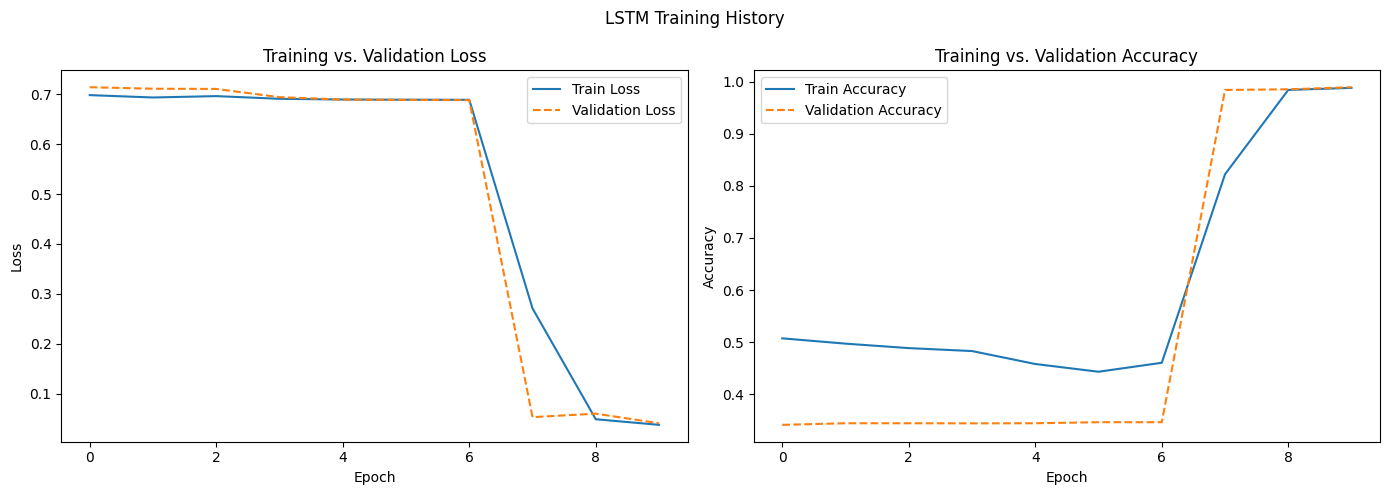

335/335 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step

Share of holdout predictions in the 0.4-0.6 'unconfident' band: 0.0%

--- LSTM — Default threshold (0.5) ---
              precision    recall  f1-score   support

      benign       0.97      1.00      0.99      3605
   malicious       1.00      0.99      0.99      7103

    accuracy                           0.99     10708
   macro avg       0.99      0.99      0.99     10708
weighted avg       0.99      0.99      0.99     10708

[[3603    2]
 [ 104 6999]]


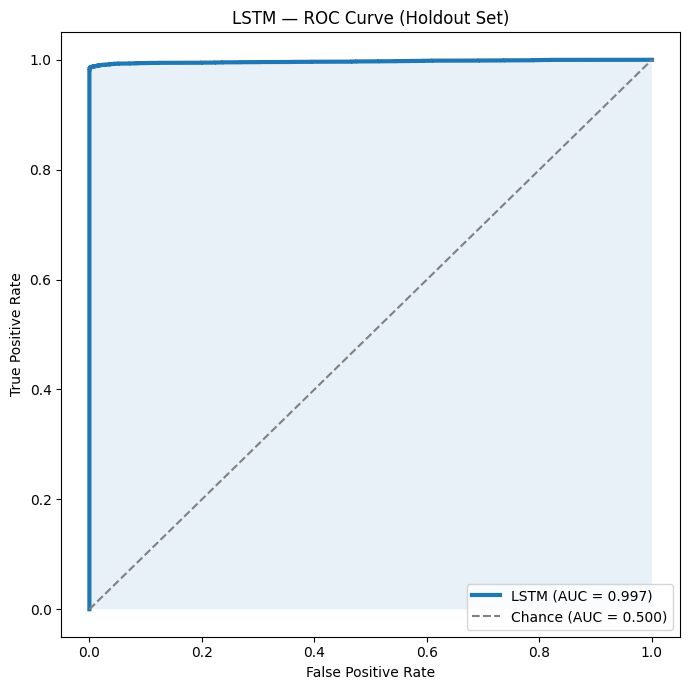


LSTM AUC: 0.9970

Best threshold for class-0 probability: 0.5994 | F1: 0.9859

--- LSTM — Tuned threshold ---
              precision    recall  f1-score   support

      benign       0.97      1.00      0.99      3605
   malicious       1.00      0.99      0.99      7103

    accuracy                           0.99     10708
   macro avg       0.99      0.99      0.99     10708
weighted avg       0.99      0.99      0.99     10708

[[3603    2]
 [ 101 7002]]


In [ ]:
# ============================================================
# STEP 5  — LSTM: CHAR-LEVEL SEQUENCE MODEL
# ============================================================
# PURPOSE
#   Train the text-only baseline directly off balanced_dataset.csv
#   (url + label only) — the LSTM never uses registrar/domain_age_days/
#   redirect_hops, so it doesn't need full_df or the WHOIS/redirect
#   feature pipeline (Step 1c / Step 3) at all. This keeps LSTM training
#   fast and independent of that heavier pipeline.
#
#   Still uses the SAME train/holdout split as the Random Forest (via
#   the persisted split from Step 2), so Step 6's error vault can align
#   both models' errors on identical holdout URLs.
#
#   Capped at 10 epochs per attempt. Includes an automatic retry: this
#   architecture can land in a stuck local optimum by initialization
#   luck alone (confirmed empirically — identical code has produced
#   AUC 0.998 and AUC 0.507 on different runs). A stuck run is detected
#   by final training loss and retried with a new seed, up to
#   MAX_ATTEMPTS times, instead of relying on manual judgment.
#
# REQUIRES
#   - balanced_dataset.csv (from Step 1b)
#   - train_holdout_split.csv (persisted split from Step 2) — OR
#     train_balanced/holdout_df already in memory from a Step 2 run
#     this session
#
# PRODUCES (in-memory, used by later steps)
#   - lstm_model, tokenizer, MAX_LEN
#   - lstm_combined, lstm_holdout_mask, y_holdout_lstm, lstm_pred,
#     lstm_pred_tuned
#   - lstm_training_history.png, lstm_roc_curve.png (saved to disk)
#
# NEXT STEP
#   step6_error_vault.py
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import models, layers, callbacks
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

RANDOM_SEED = 42

# ------------------------------------------------------------
# 1. Load balanced_dataset.csv directly — text + label only, no
#    WHOIS/redirect features needed
# ------------------------------------------------------------
if not os.path.exists("balanced_dataset.csv"):
    raise FileNotFoundError("balanced_dataset.csv not found — run Step 1b first.")

raw = pd.read_csv("balanced_dataset.csv", dtype={"url_id": str})
raw["url_id"] = raw["url_id"].astype(str)

# minimal normalization — just ensures a scheme prefix, matching Step 2's
# normalize_url so tokenization sees consistent text
import re
def add_scheme(url):
    url = str(url)
    return url if re.match(r'^[a-zA-Z]+://', url) else "http://" + url

raw["normalized_url"] = raw["url"].apply(add_scheme)
raw["is_malicious"] = (raw["label"] != "benign").astype(int)

# ------------------------------------------------------------
# 2. Gets the SAME train/holdout split used by the Random Forest, so
#    Step 6 can align both models' errors on identical holdout URLs
# ------------------------------------------------------------
SPLIT_FILE = "train_holdout_split.csv"

if "train_balanced" in globals() and "holdout_df" in globals():
    train_ids = set(train_balanced["url_id"].astype(str))
    holdout_ids = set(holdout_df["url_id"].astype(str))
    print("Using train/holdout split already in memory from Step 2.")
elif os.path.exists(SPLIT_FILE):
    split_assignment = pd.read_csv(SPLIT_FILE, dtype={"url_id": str})
    train_ids = set(split_assignment.loc[split_assignment["split"] == "train", "url_id"])
    holdout_ids = set(split_assignment.loc[split_assignment["split"] == "holdout", "url_id"])
    print(f"Loaded persisted split from {SPLIT_FILE}.")
else:
    raise FileNotFoundError(
        "No train/holdout split found — run step2_load_and_split.py at least once "
        "(it persists the split to train_holdout_split.csv for reuse)."
    )

lstm_combined = raw[raw["url_id"].isin(train_ids | holdout_ids)].reset_index(drop=True)
lstm_train_mask = lstm_combined["url_id"].isin(train_ids)
lstm_holdout_mask = lstm_combined["url_id"].isin(holdout_ids)

print(f"Train rows: {lstm_train_mask.sum()} | Holdout rows: {lstm_holdout_mask.sum()}")

# ------------------------------------------------------------
# 3. Builds char-level sequences
# ------------------------------------------------------------
tokenizer = Tokenizer(char_level=True, oov_token="<OOV>")
tokenizer.fit_on_texts(lstm_combined.loc[lstm_train_mask, "normalized_url"])

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size (unique characters + OOV):", vocab_size)

url_lengths = lstm_combined["normalized_url"].str.len()
MAX_LEN = int(np.percentile(url_lengths, 99))
print("Max sequence length (99th percentile):", MAX_LEN, "| longest URL:", url_lengths.max())

all_sequences = tokenizer.texts_to_sequences(lstm_combined["normalized_url"])
padded = pad_sequences(all_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
lstm_combined["char_sequence"] = list(padded)

# ------------------------------------------------------------
# 4. Train/val split
# ------------------------------------------------------------
X_seq_train_all = np.array(lstm_combined.loc[lstm_train_mask, "char_sequence"].tolist())
y_train_all = lstm_combined.loc[lstm_train_mask, "is_malicious"].values
X_seq_holdout = np.array(lstm_combined.loc[lstm_holdout_mask, "char_sequence"].tolist())
y_holdout_lstm = lstm_combined.loc[lstm_holdout_mask, "is_malicious"].values

print("LSTM train class balance:", pd.Series(y_train_all).value_counts().to_dict())
print("LSTM holdout class balance:", pd.Series(y_holdout_lstm).value_counts().to_dict())

X_tr, X_val, y_tr, y_val = train_test_split(
    X_seq_train_all, y_train_all, test_size=0.15, stratify=y_train_all, random_state=RANDOM_SEED
)

classes = np.unique(y_tr)
raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weight_dict = {int(k): float(v) for k, v in zip(classes, raw_weights)}
print("Class weights:", class_weight_dict)

# ------------------------------------------------------------
# 5. Train with automatic retry on a stuck run — capped at 10 epochs
#    per attempt
# ------------------------------------------------------------
EPOCHS_PER_ATTEMPT = 10
MAX_ATTEMPTS = 4

def train_lstm_once(seed_offset=0):
    tf.random.set_seed(RANDOM_SEED + seed_offset)
    model = models.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=32),
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    model.build(input_shape=(None, MAX_LEN))

    hist = model.fit(
        X_tr, y_tr, validation_data=(X_val, y_val),
        epochs=EPOCHS_PER_ATTEMPT, batch_size=64, shuffle=True,
        class_weight=class_weight_dict,
        callbacks=[
            callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5, verbose=1),
        ],
        verbose=1,
    )
    return model, hist

lstm_model = None
history = None
candidate_model, candidate_history = None, None

for attempt in range(1, MAX_ATTEMPTS + 1):
    print(f"\n{'='*60}\nLSTM training attempt {attempt}/{MAX_ATTEMPTS} "
          f"({EPOCHS_PER_ATTEMPT} epochs)\n{'='*60}")
    candidate_model, candidate_history = train_lstm_once(seed_offset=attempt)

    final_train_loss = candidate_history.history["loss"][-1]
    if final_train_loss > 0.4:
        print(f"Attempt {attempt}: final train loss {final_train_loss:.4f} still near the "
              f"random-guessing baseline (0.693) — this run got stuck. Retrying with a new seed.")
        continue

    lstm_model = candidate_model
    history = candidate_history
    print(f"Attempt {attempt}: converged (final train loss {final_train_loss:.4f}). Proceeding.")
    break

if lstm_model is None:
    print(f"\nWARNING: all {MAX_ATTEMPTS} attempts got stuck near the random-guessing baseline "
          f"within {EPOCHS_PER_ATTEMPT} epochs each. Using the last attempt's model, but results "
          f"should be treated as unreliable — consider MAX_ATTEMPTS or EPOCHS_PER_ATTEMPT higher.")
    lstm_model, history = candidate_model, candidate_history

lstm_model.summary()

# ------------------------------------------------------------
# 6. Training history plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss", linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs. Validation Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs. Validation Accuracy"); axes[1].legend()

plt.suptitle("LSTM Training History")
plt.tight_layout()
plt.savefig("lstm_training_history.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# 7. Evaluate on holdout (default 0.5 threshold)
# ------------------------------------------------------------
lstm_pred_proba = lstm_model.predict(X_seq_holdout).ravel()
lstm_pred = (lstm_pred_proba >= 0.5).astype(int)

near_half = ((lstm_pred_proba > 0.4) & (lstm_pred_proba < 0.6)).mean()
print(f"\nShare of holdout predictions in the 0.4-0.6 'unconfident' band: {near_half:.1%}")
if near_half > 0.3:
    print("WARNING: >30% of predictions are clustered near 0.5 — model may still be "
          "undertrained/underconfident despite passing the retry check.")

print("\n--- LSTM — Default threshold (0.5) ---")
print(classification_report(y_holdout_lstm, lstm_pred, target_names=["benign", "malicious"], zero_division=0))
print(confusion_matrix(y_holdout_lstm, lstm_pred))

# ------------------------------------------------------------
# 8. ROC curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_holdout_lstm, lstm_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, linewidth=3, label=f"LSTM (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("LSTM — ROC Curve (Holdout Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("lstm_roc_curve.png", dpi=150)
plt.show()
print(f"\nLSTM AUC: {roc_auc:.4f}")

# ------------------------------------------------------------
# 9. Threshold tuning
# ------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_holdout_lstm == 0, 1 - lstm_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_benign_proba = thresholds[best_idx]

print(f"\nBest threshold for class-0 probability: {best_threshold_benign_proba:.4f} | F1: {f1_scores[best_idx]:.4f}")

lstm_pred_tuned = (1 - lstm_pred_proba < best_threshold_benign_proba).astype(int)
print("\n--- LSTM — Tuned threshold ---")
print(classification_report(y_holdout_lstm, lstm_pred_tuned, target_names=["benign", "malicious"], zero_division=0))
print(confusion_matrix(y_holdout_lstm, lstm_pred_tuned))

#Step:6 error vault

In [ ]:
# ============================================================
# STEP 6 — THE ERROR VAULT (misclassifications, both models)
# ============================================================
# PURPOSE
#   Collect every false positive and false negative from BOTH models
#   into one SQLite table. This is the diagnostic tool's core artifact:
#   everything downstream (SHAP, LIME, feature comparison) operates
#   ONLY on this error set, never on correctly-classified samples —
#   keeping the project's focus on failure analysis, not prediction.
#
# REQUIRES
#   - rf_pred, y_holdout, X_holdout, full_df_rf, rf_holdout_mask (Step 4)
#   - lstm_pred, y_holdout_lstm, lstm_combined, lstm_holdout_mask (Step 5)
#
# PRODUCES
#   - error_vault.db  (SQLite database)
#   - error_vault_df, holdout_records (in-memory, used by later steps)
#   - conn, cur  (open SQLite connection/cursor, reused by Steps 7-8)
#
# NEXT STEP
#   step7_shap_analysis.py
# ============================================================

import sqlite3
import json
import numpy as np
import pandas as pd

def _json_safe(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

conn = sqlite3.connect("error_vault.db")
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS error_vault")
cur.execute("""
CREATE TABLE IF NOT EXISTS error_vault (
    url_id TEXT,
    model TEXT,
    error_type TEXT,
    url TEXT,
    features_json TEXT,
    true_label INTEGER,
    predicted_label INTEGER
)
""")

def error_type(t, p):
    if t == 0 and p == 1:
        return "false_positive"
    if t == 1 and p == 0:
        return "false_negative"
    return None

holdout_records = full_df_rf.loc[rf_holdout_mask].reset_index(drop=True)
holdout_records["url_id"] = holdout_records["url_id"].astype(str)

n = min(len(holdout_records), len(y_holdout), len(rf_pred))
print("Using records:", n)

y_holdout_np = np.asarray(y_holdout[:n])
rf_pred_np = np.asarray(rf_pred[:n])

lstm_holdout_records = None
if "lstm_pred_tuned" in globals():
    lstm_holdout_records = lstm_combined.loc[lstm_holdout_mask].reset_index(drop=True)

    lstm_holdout_records["url_id"] = lstm_holdout_records["url_id"].astype(str)

    active_lstm_pred = lstm_pred_tuned
    print(f"Using threshold-tuned LSTM predictions for the error vault "
          f"(best_threshold_benign_proba from Step 5).")
elif "lstm_pred" in globals():
    lstm_holdout_records = lstm_combined.loc[lstm_holdout_mask].reset_index(drop=True)
    active_lstm_pred = lstm_pred
    print("WARNING: lstm_pred_tuned not found — falling back to the untuned default-threshold "
          "predictions. If these show a degenerate all-one-class error pattern, rerun Step 5 "
          "fully (including the threshold-tuning cell) before proceeding.")

NUMERIC_COLS = ["url_length", "char_entropy", "hyphen_count", "question_count", "dot_count",
                "subdomain_count", "redirect_hops", "is_shortener", "domain_age_days"]

rows = []
for i in range(n):
    record = holdout_records.iloc[i]
    true_label = int(y_holdout_np[i])
    rf_error = error_type(true_label, int(rf_pred_np[i]))

    if rf_error:
        rows.append((
            str(record["url_id"]), "random_forest", rf_error, str(record["normalized_url"]),
            json.dumps(X_holdout.iloc[i].to_dict(), default=_json_safe),
            true_label, int(rf_pred_np[i])
        ))

    if lstm_holdout_records is not None and i < len(active_lstm_pred):
        match = lstm_holdout_records[lstm_holdout_records["url_id"] == record["url_id"]]
        if not match.empty:
            lstm_row = match.iloc[0]
            lstm_true = int(lstm_row["is_malicious"])
            lstm_idx = match.index[0]
            lstm_error = error_type(lstm_true, int(active_lstm_pred[lstm_idx]))
            if lstm_error:
                rows.append((
                    str(record["url_id"]), "lstm", lstm_error, str(record["normalized_url"]),
                    json.dumps({col: record.get(col, None) for col in NUMERIC_COLS}, default=_json_safe),
                    lstm_true, int(active_lstm_pred[lstm_idx])
                ))

cur.executemany("INSERT INTO error_vault VALUES (?,?,?,?,?,?,?)", rows)
conn.commit()

error_vault_df = pd.read_sql("SELECT * FROM error_vault", conn)
print("\nError Summary:")
print(error_vault_df.groupby(["model", "error_type"]).size())
print("\nTotal stored errors:", len(error_vault_df))

Using records: 10708
Using threshold-tuned LSTM predictions for the error vault (best_threshold_benign_proba from Step 5).

Error Summary:
model          error_type    
lstm           false_negative    101
               false_positive      2
random_forest  false_negative    217
               false_positive    182
dtype: int64

Total stored errors: 502


#step :7 shap analysis

SHAP will explain 399 misclassified RF rows
Training columns: 36
X_rf_errors columns: 36
Columns match exactly: True
SHAP values shape: (399, 36) | expected: (399, 36)


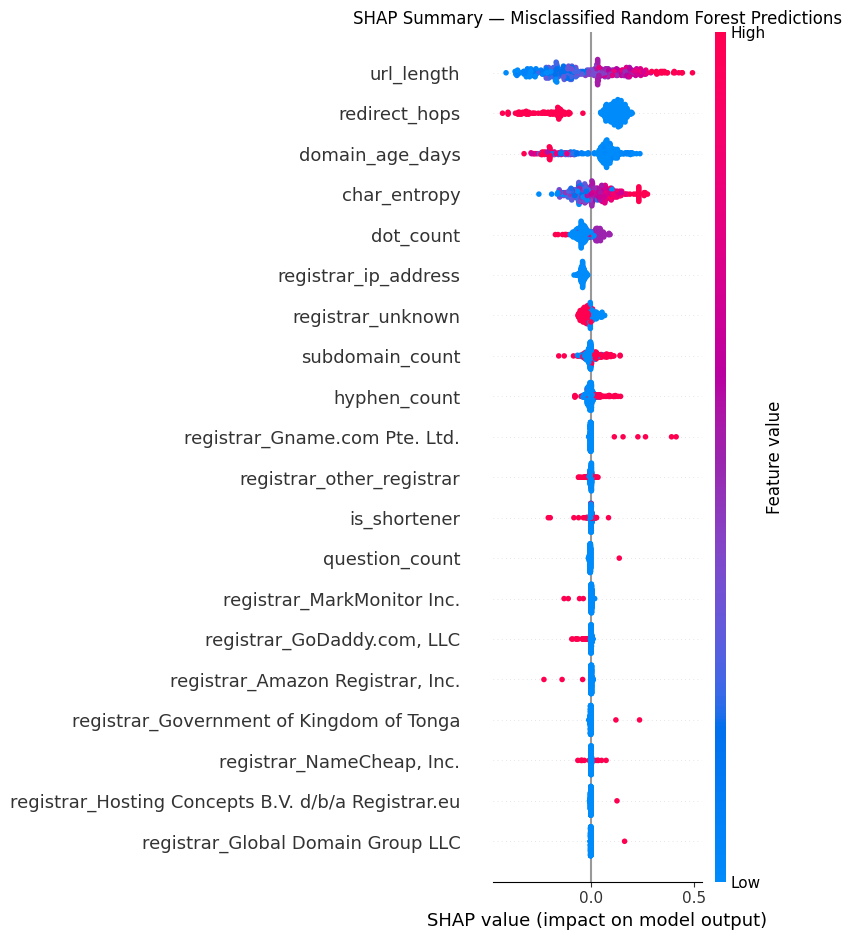

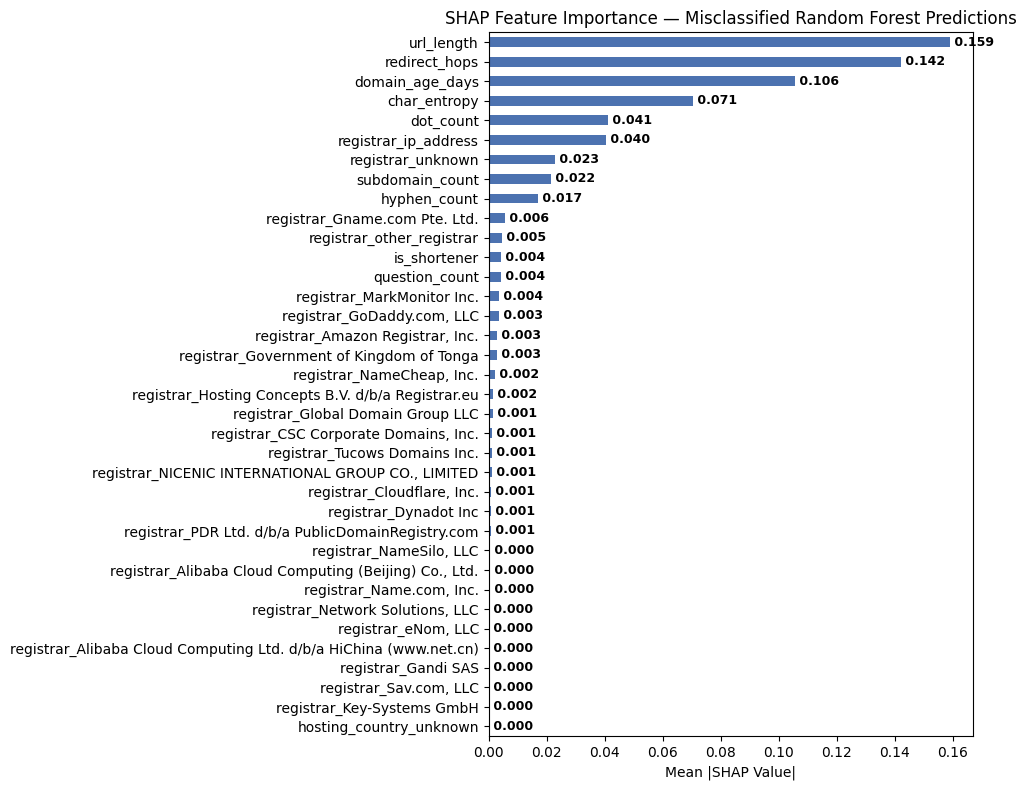

Stored 399 SHAP attributions
Cluster 0: n=65, dominant features: ['domain_age_days', 'redirect_hops', 'char_entropy']
Cluster 1: n=184, dominant features: ['url_length', 'redirect_hops', 'domain_age_days']
Cluster 2: n=45, dominant features: ['redirect_hops', 'url_length', 'domain_age_days']
Cluster 3: n=105, dominant features: ['url_length', 'redirect_hops', 'domain_age_days']


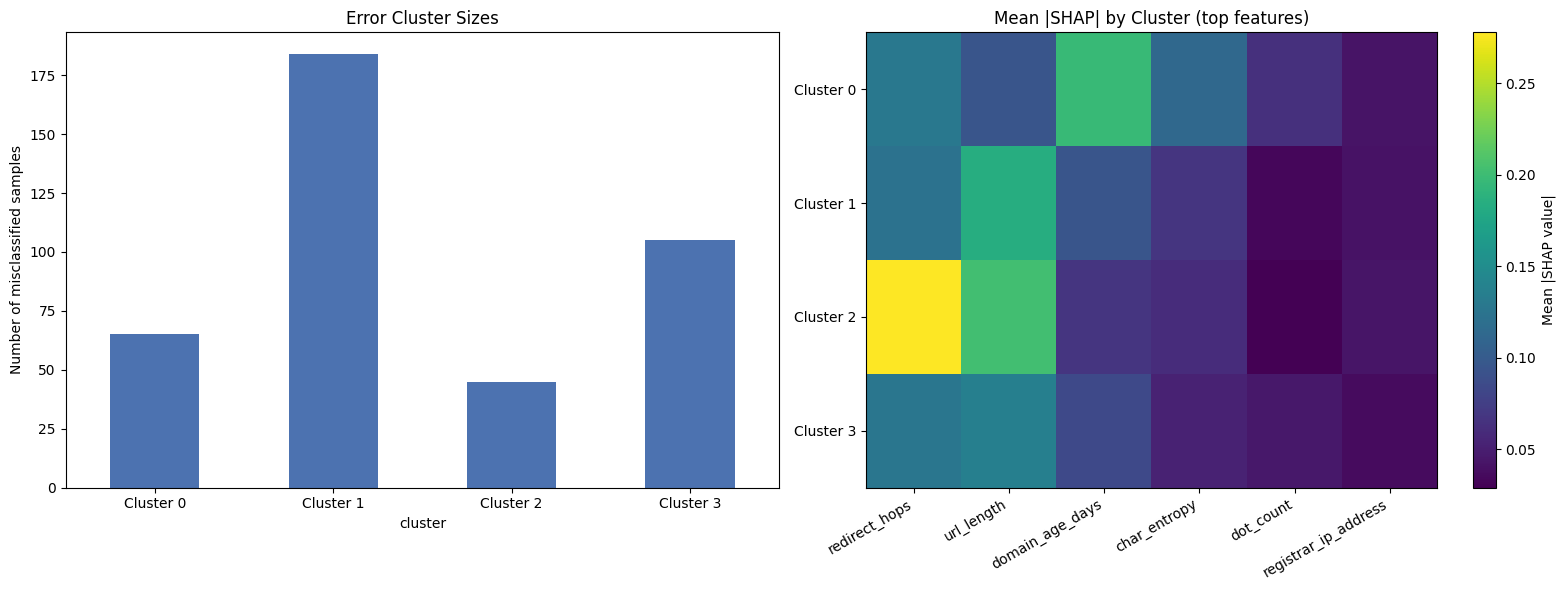

In [ ]:
# ============================================================
# STEP 7 — SHAP: EXPLAIN MISCLASSIFIED RANDOM FOREST PREDICTIONS
# ============================================================
# PURPOSE
#   Run SHAP (TreeExplainer) ONLY on the Random Forest's misclassified
#   holdout rows (from the error vault) — never on correct predictions.
#   Produces a beeswarm summary + importance bar chart, then clusters
#   the errors by SHAP attribution pattern (KMeans) to surface distinct
#   failure modes rather than one blended average.
#
# REQUIRES
#   - rf_model, X_train, X_holdout (from Step 4)
#   - holdout_records, error_vault_df, conn, cur (from Step 6)
#
# PRODUCES
#   - shap_explanations table in error_vault.db
#   - shap_beeswarm.png, shap_feature_importance.png,
#     fig_shap_clusters.png (saved to disk)
#
# NEXT STEP
#   step8_lime_analysis.py
# ============================================================

import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

X_holdout_reset = X_holdout.reset_index(drop=True)

rf_error_ids = error_vault_df.loc[error_vault_df["model"] == "random_forest", "url_id"].astype(str).tolist()
mask = holdout_records["url_id"].astype(str).isin(rf_error_ids)

X_rf_errors = X_holdout_reset.loc[mask]
error_url_ids = holdout_records.loc[mask, "url_id"]

print("SHAP will explain", len(X_rf_errors), "misclassified RF rows")
assert len(X_rf_errors) > 0, "Mask matched zero rows — check url_id dtype alignment before proceeding"

print("Training columns:", len(X_train.columns))
print("X_rf_errors columns:", len(X_rf_errors.columns))
print("Columns match exactly:", list(X_train.columns) == list(X_rf_errors.columns))

explainer_rf = shap.TreeExplainer(rf_model)

try:
    shap_values = explainer_rf.shap_values(X_rf_errors, check_additivity=True)
except Exception as e:
    print(f"Additivity check still failing after the cardinality fix: {e}")
    print("Falling back to check_additivity=False — but this is now worth flagging "
          "as a real limitation in your writeup rather than a silent workaround.")
    shap_values = explainer_rf.shap_values(X_rf_errors, check_additivity=False)

if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

print("SHAP values shape:", shap_pos.shape, "| expected:", X_rf_errors.shape)

# Summary plot
shap.summary_plot(shap_pos, X_rf_errors, show=False)
plt.title("SHAP Summary — Misclassified Random Forest Predictions")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot of mean |SHAP|
mean_abs_shap = pd.Series(np.abs(shap_pos).mean(axis=0), index=X_rf_errors.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
mean_abs_shap.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("SHAP Feature Importance — Misclassified Random Forest Predictions")
for i, v in enumerate(mean_abs_shap):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150)
plt.show()

def _json_safe(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

cur.execute("DROP TABLE IF EXISTS shap_explanations")
cur.execute("CREATE TABLE IF NOT EXISTS shap_explanations (url_id TEXT, attribution_json TEXT)")
for idx, uid in enumerate(error_url_ids):
    cur.execute(
        "INSERT INTO shap_explanations VALUES (?,?)",
        (str(uid), json.dumps(dict(zip(X_rf_errors.columns, shap_pos[idx])), default=_json_safe))
    )
conn.commit()
print("Stored", len(error_url_ids), "SHAP attributions")

# ------------------------------------------------------------
# Cluster misclassifications by SHAP attribution pattern
# ------------------------------------------------------------
from sklearn.cluster import KMeans

shap_df = pd.read_sql("SELECT * FROM shap_explanations", conn)
attribution_matrix = pd.DataFrame([json.loads(a) for a in shap_df["attribution_json"]]).fillna(0)

if len(attribution_matrix) >= 4:
    k = min(4, len(attribution_matrix) // 5) or 2
    shap_df["cluster"] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(attribution_matrix)

    for c in sorted(shap_df["cluster"].unique()):
        top = attribution_matrix.loc[shap_df["cluster"] == c].abs().mean().sort_values(ascending=False)
        print(f"Cluster {c}: n={sum(shap_df['cluster']==c)}, dominant features: {list(top.head(3).index)}")

    # Cluster size + dominant-feature heatmap plot
    cluster_sizes = shap_df["cluster"].value_counts().sort_index()
    top_features_per_cluster = {
        c: attribution_matrix.loc[shap_df["cluster"] == c].abs().mean()
        for c in sorted(shap_df["cluster"].unique())
    }
    heat_df = pd.DataFrame(top_features_per_cluster).T
    top_cols = heat_df.mean().sort_values(ascending=False).head(6).index
    heat_df = heat_df[top_cols]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cluster_sizes.plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("Error Cluster Sizes")
    axes[0].set_ylabel("Number of misclassified samples")
    axes[0].set_xticklabels([f"Cluster {i}" for i in cluster_sizes.index], rotation=0)

    im = axes[1].imshow(heat_df.values, cmap="viridis", aspect="auto")
    axes[1].set_xticks(range(len(top_cols))); axes[1].set_xticklabels(top_cols, rotation=30, ha="right")
    axes[1].set_yticks(range(len(heat_df))); axes[1].set_yticklabels([f"Cluster {i}" for i in heat_df.index])
    axes[1].set_title("Mean |SHAP| by Cluster (top features)")
    plt.colorbar(im, ax=axes[1], label="Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig("fig_shap_clusters.png", dpi=150)
    plt.show()
else:
    print("Not enough errors yet to form stable clusters.")

#step :8 lime analysis

LIME will explain 103 misclassified LSTM rows
Stored 103 LIME explanations

Top tokens by |mean LIME weight| across misclassified LSTM predictions (pooled):
                                  mean  count
token                                        
312756                        0.643853      1
melbet                        0.640776      1
2992ghohgoho                  0.444750      1
tiktokpangle                  0.396061      1
oferta12                      0.381937      1
ourgreenpalace                0.317592      1
allegro                       0.286989      2
cam                          -0.225204      1
lokalna                       0.221195      1
telewexs                      0.212711      1
ssuporteacessoempresariall    0.212647      1
acessoexclusivopjnetempresas  0.202693      1
b                             0.195919      1
onlinepersonasenlinea         0.186564      1
ciuoinbasewalletexteensiion   0.178858      1
click                         0.178843      1
access         

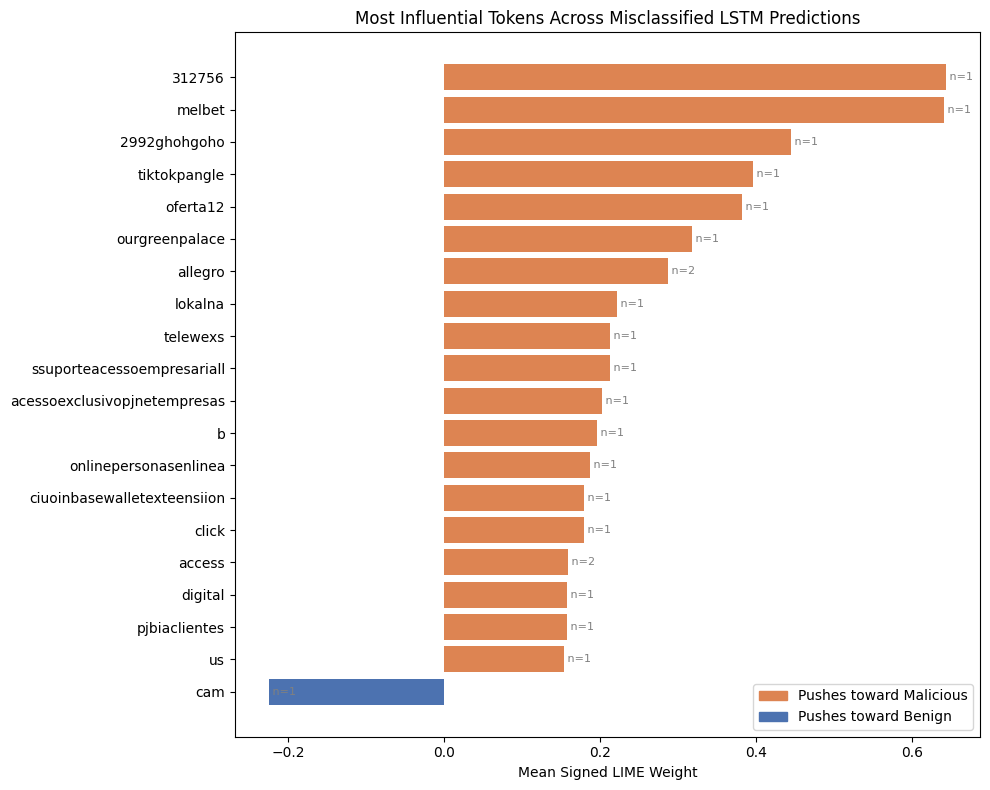

In [ ]:
# ============================================================
# STEP 8 — LIME: EXPLAIN MISCLASSIFIED LSTM PREDICTIONS
# ============================================================
# PURPOSE
#   Run LIME (LimeTextExplainer) ONLY on the LSTM's misclassified
#   holdout URLs (from the error vault) — never on correct predictions.
#   Produces per-URL token attributions plus an aggregate "most
#   influential tokens" chart across all explained misclassifications.
#   Capped at MAX_LIME_INSTANCES since LIME re-predicts many times per
#   instance and can be slow on a large error set.
#
# REQUIRES
#   - lstm_model, tokenizer, MAX_LEN (from Step 5)
#   - holdout_records, error_vault_df, conn, cur (from Step 6)
#
# PRODUCES
#   - lime_explanations table in error_vault.db
#   - lime_aggregate_token_importance.png (saved to disk)
#
# NEXT STEP
#   step9_feature_comparison.py
# ============================================================

import json
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
from lime.lime_text import LimeTextExplainer

lstm_error_ids = error_vault_df.loc[error_vault_df["model"] == "lstm", "url_id"].astype(str).tolist()
lstm_error_mask = holdout_records["url_id"].astype(str).isin(lstm_error_ids)

lstm_error_records = holdout_records.loc[lstm_error_mask, ["url_id", "normalized_url"]]
lstm_error_urls = lstm_error_records["normalized_url"].tolist()
lstm_error_ids_ordered = lstm_error_records["url_id"].tolist()

print("LIME will explain", len(lstm_error_urls), "misclassified LSTM rows")
assert len(lstm_error_urls) > 0, "Mask matched zero rows — check url_id dtype alignment before proceeding"

def encode_url(url):
    seq = tokenizer.texts_to_sequences([url])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    return padded[0]

def lstm_predict_proba(urls):
    proba = lstm_model.predict(np.array([encode_url(u) for u in urls]), verbose=0).ravel()
    return np.column_stack([1 - proba, proba])

def _json_safe(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

explainer = LimeTextExplainer(class_names=["benign", "malicious"], split_expression=r'\W+')

cur.execute("DROP TABLE IF EXISTS lime_explanations")
cur.execute("CREATE TABLE IF NOT EXISTS lime_explanations (url_id TEXT, token_weights_json TEXT)")

# NOTE: with a larger holdout set now (thousands of rows vs. dozens),
# running LIME on every single misclassified URL individually can be
# slow —
MAX_LIME_INSTANCES = 300
if len(lstm_error_urls) > MAX_LIME_INSTANCES:
    print(f"Capping LIME to a random sample of {MAX_LIME_INSTANCES} "
          f"(of {len(lstm_error_urls)} total misclassified URLs) to keep runtime reasonable.")
    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(lstm_error_urls), size=MAX_LIME_INSTANCES, replace=False)
    lstm_error_urls = [lstm_error_urls[i] for i in sample_idx]
    lstm_error_ids_ordered = [lstm_error_ids_ordered[i] for i in sample_idx]

for uid, url in zip(lstm_error_ids_ordered, lstm_error_urls):
    exp = explainer.explain_instance(url, lstm_predict_proba, num_features=8)
    cur.execute(
        "INSERT INTO lime_explanations VALUES (?,?)",
        (str(uid), json.dumps(dict(exp.as_list()), default=_json_safe))
    )

conn.commit()
print("Stored", len(lstm_error_ids_ordered), "LIME explanations")

# ------------------------------------------------------------
# Aggregate token importance across all explained misclassifications
# ------------------------------------------------------------
lime_df = pd.read_sql("SELECT * FROM lime_explanations", conn)
token_records = []
for _, row in lime_df.iterrows():
    weights = json.loads(row["token_weights_json"])
    for token, weight in weights.items():
        token_records.append({"token": token, "weight": weight})

token_df = pd.DataFrame(token_records)
agg = token_df.groupby("token")["weight"].agg(["mean", "count"]).sort_values("mean", key=abs, ascending=False)
print("\nTop tokens by |mean LIME weight| across misclassified LSTM predictions (pooled):")
print(agg.head(20))

# ------------------------------------------------------------
# Split by error type — pooling FP and FN hides which tokens drive
# false alarms (benign wrongly flagged malicious) versus which let
# genuine malicious URLs slip through undetected. The second category
# matters more for a security tool, and it can get crowded out of a
# pooled top-20 if FP-driven signal happens to have larger magnitude.
# ------------------------------------------------------------
error_type_by_id = dict(zip(
    error_vault_df.loc[error_vault_df["model"] == "lstm", "url_id"].astype(str),
    error_vault_df.loc[error_vault_df["model"] == "lstm", "error_type"]
))

token_records_typed = []
for _, row in lime_df.iterrows():
    err_type = error_type_by_id.get(str(row["url_id"]), "unknown")
    weights = json.loads(row["token_weights_json"])
    for token, weight in weights.items():
        token_records_typed.append({"token": token, "weight": weight, "error_type": err_type})

token_df_typed = pd.DataFrame(token_records_typed)

for err_type in ["false_positive", "false_negative"]:
    subset = token_df_typed[token_df_typed["error_type"] == err_type]
    if len(subset) == 0:
        continue
    agg_subset = subset.groupby("token")["weight"].agg(["mean", "count"]).sort_values(
        "mean", key=abs, ascending=False
    )
    label = "false alarms (benign -> predicted malicious)" if err_type == "false_positive" \
        else "missed detections (malicious -> predicted benign)"
    print(f"\nTop tokens for {err_type} — {label}:")
    print(agg_subset.head(15))

import matplotlib.pyplot as plt

top20 = agg.head(20).sort_values("mean")
colors = ["#DD8452" if w > 0 else "#4C72B0" for w in top20["mean"]]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20.index, top20["mean"], color=colors)
ax.set_xlabel("Mean Signed LIME Weight")
ax.set_title("Most Influential Tokens Across Misclassified LSTM Predictions")
for i, (m, c) in enumerate(zip(top20["mean"], top20["count"])):
    ax.text(m, i, f" n={c}", va="center", fontsize=8, color="gray")
handles = [plt.Rectangle((0, 0), 1, 1, color="#DD8452"), plt.Rectangle((0, 0), 1, 1, color="#4C72B0")]
ax.legend(handles, ["Pushes toward Malicious", "Pushes toward Benign"], loc="lower right")
plt.tight_layout()
plt.savefig("lime_aggregate_token_importance.png", dpi=150)
plt.show()

#step :9 feature comparison

False positives (all models pooled):
  (matched 182 of 184 ids)
False negatives (all models pooled):
  (matched 296 of 318 ids)
                 false_positive  false_negative  holdout_overall
url_length            27.065934       25.091216        37.528203
char_entropy           3.873002        3.832214         3.954776
hyphen_count           0.379121        0.233108         0.379156
question_count         0.000000        0.003378         0.052484
dot_count              1.604396        1.327703         2.168192
subdomain_count        0.532967        0.266892         0.270078
redirect_hops          0.137363        0.283784         0.343015
is_shortener           0.038462        0.141892         0.025215
domain_age_days      413.368132     1479.101351      1346.364681


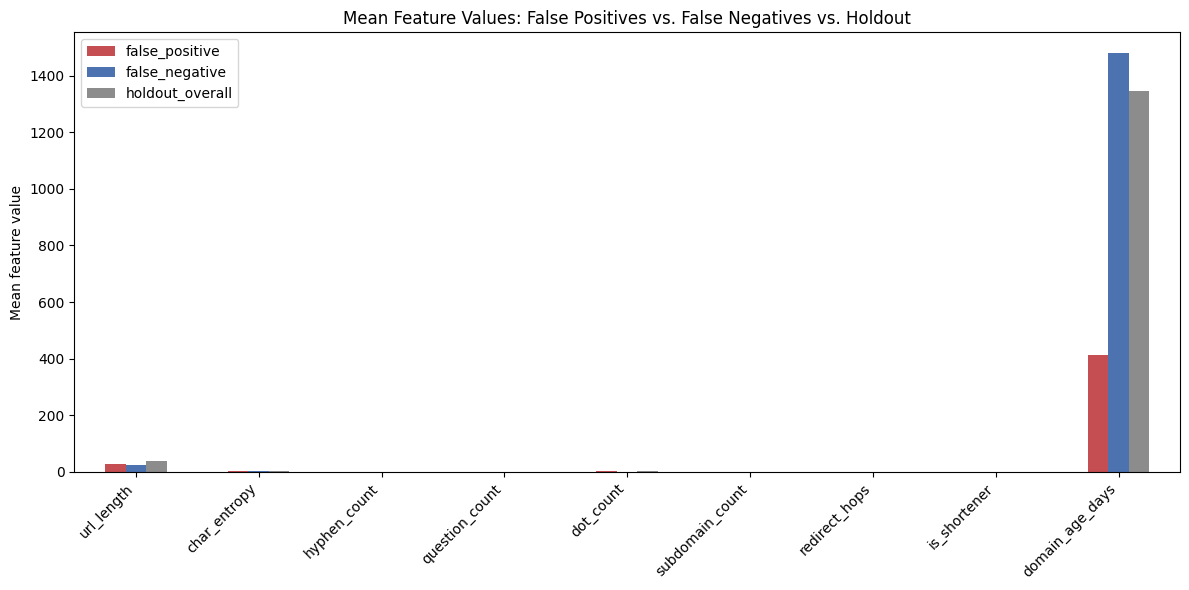


random_forest / false_positive (n=182):
  (matched 182 of 182 ids)

random_forest / false_negative (n=217):
  (matched 217 of 217 ids)

lstm / false_positive (n=2):
  (matched 2 of 2 ids)

lstm / false_negative (n=101):
  (matched 101 of 101 ids)


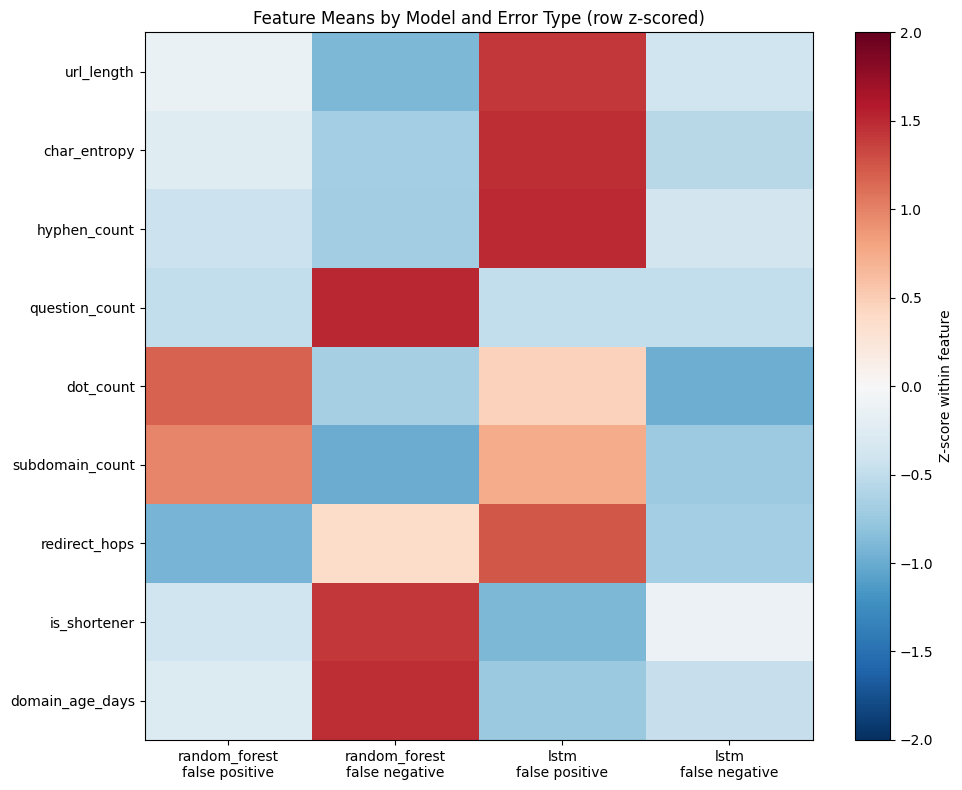

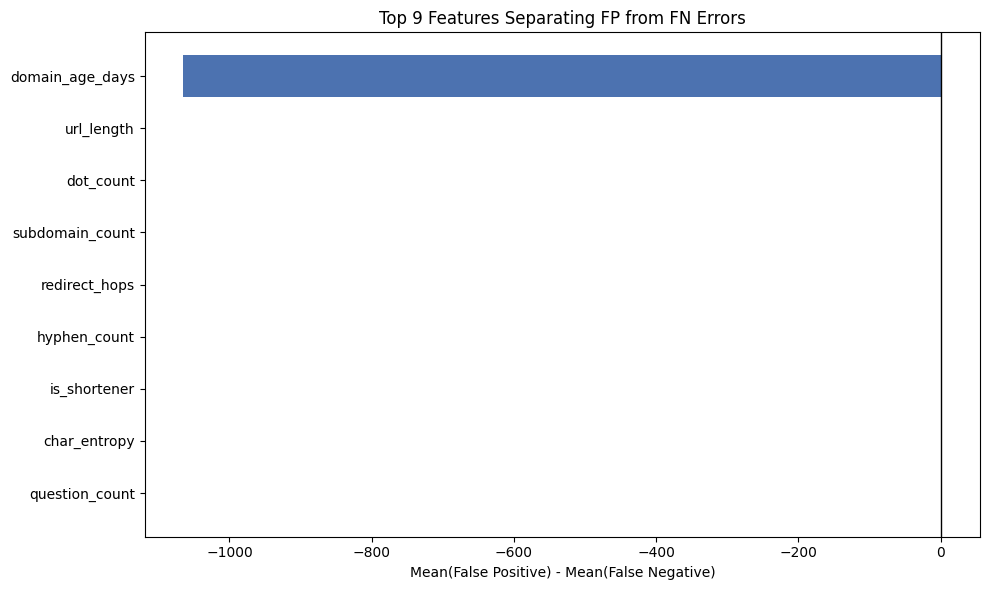


Top features separating FP from FN (sorted by |difference|):
domain_age_days   -1065.733219
url_length            1.974718
dot_count             0.276693
subdomain_count       0.266075
redirect_hops        -0.146421
hyphen_count          0.146013
is_shortener         -0.103430
char_entropy          0.040788
question_count       -0.003378
dtype: float64


In [ ]:
# ============================================================
# STEP 9 — FEATURE COMPARISON: FP vs. FN vs. HOLDOUT, BY MODEL
# ============================================================
# PURPOSE
#   Final diagnostic synthesis: compare mean feature values between
#   false positives, false negatives, and the overall holdout set,
#   both pooled across models and broken out per-model (RF vs. LSTM
#   may fail on structurally different URLs — pooling would hide that).
#   Ends with a diverging bar chart of the features that most separate
#   FP from FN errors;
#
# REQUIRES
#   - full_df, full_df_rf, rf_holdout_mask (from Steps 3-4)
#   - error_vault_df (from Step 6)
#
# PRODUCES
#   - model_error_comparison.png, fig_per_model_heatmap.png,
#     fig_fp_fn_diverging.png (saved to disk)
#
# This is the last step in the pipeline.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

full_df["url_id"] = full_df["url_id"].astype(str)

NUMERIC_COLS = ["url_length", "char_entropy", "hyphen_count", "question_count", "dot_count",
                "subdomain_count", "redirect_hops", "is_shortener", "domain_age_days"]

fp_ids = error_vault_df.loc[error_vault_df["error_type"] == "false_positive", "url_id"].astype(str)
fn_ids = error_vault_df.loc[error_vault_df["error_type"] == "false_negative", "url_id"].astype(str)

def mean_feats(ids):
    subset = full_df[full_df["url_id"].isin(ids)]
    print(f"  (matched {len(subset)} of {len(ids)} ids)")
    return subset[NUMERIC_COLS].mean()

holdout_url_ids = full_df_rf.loc[rf_holdout_mask, "url_id"].astype(str)

print("False positives (all models pooled):")
fp_means = mean_feats(fp_ids)
print("False negatives (all models pooled):")
fn_means = mean_feats(fn_ids)

comparison = pd.DataFrame({
    "false_positive": fp_means,
    "false_negative": fn_means,
    "holdout_overall": full_df[full_df["url_id"].isin(holdout_url_ids)][NUMERIC_COLS].mean(),
})
print(comparison)

# ------------------------------------------------------------
# Plot: FP vs FN vs holdout overall
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
comparison.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0", "#8C8C8C"])
ax.set_ylabel("Mean feature value")
ax.set_title("Mean Feature Values: False Positives vs. False Negatives vs. Holdout")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("model_error_comparison.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Per-model breakdown
# ------------------------------------------------------------
per_model_rows = {}
for model_name in error_vault_df["model"].unique():
    for err_type in ["false_positive", "false_negative"]:
        ids = error_vault_df.loc[
            (error_vault_df["model"] == model_name) & (error_vault_df["error_type"] == err_type), "url_id"
        ].astype(str)
        if len(ids) > 0:
            print(f"\n{model_name} / {err_type} (n={len(ids)}):")
            per_model_rows[f"{model_name}\n{err_type.replace('_',' ')}"] = mean_feats(ids)

per_model_df = pd.DataFrame(per_model_rows)

# Row z-score the per-model comparison so features on wildly different
# scales (url_length in the hundreds vs. is_shortener 0/1) are all
# visible in one heatmap
z_scored = per_model_df.sub(per_model_df.mean(axis=1), axis=0).div(per_model_df.std(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(z_scored.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(z_scored.columns))); ax.set_xticklabels(z_scored.columns, rotation=0)
ax.set_yticks(range(len(z_scored.index))); ax.set_yticklabels(z_scored.index)
ax.set_title("Feature Means by Model and Error Type (row z-scored)")
plt.colorbar(im, label="Z-score within feature")
plt.tight_layout()
plt.savefig("fig_per_model_heatmap.png", dpi=150)
plt.show()

# ------------------------------------------------------------
# Diverging bar chart: which features most separate FP from FN
# ------------------------------------------------------------
diff = (fp_means - fn_means).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in diff]
ax.barh(diff.index[::-1], diff.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Mean(False Positive) - Mean(False Negative)")
ax.set_title(f"Top {len(diff)} Features Separating FP from FN Errors")
plt.tight_layout()
plt.savefig("fig_fp_fn_diverging.png", dpi=150)
plt.show()

print("\nTop features separating FP from FN (sorted by |difference|):")
print(diff)

#STEP 10 VISUALIZATION

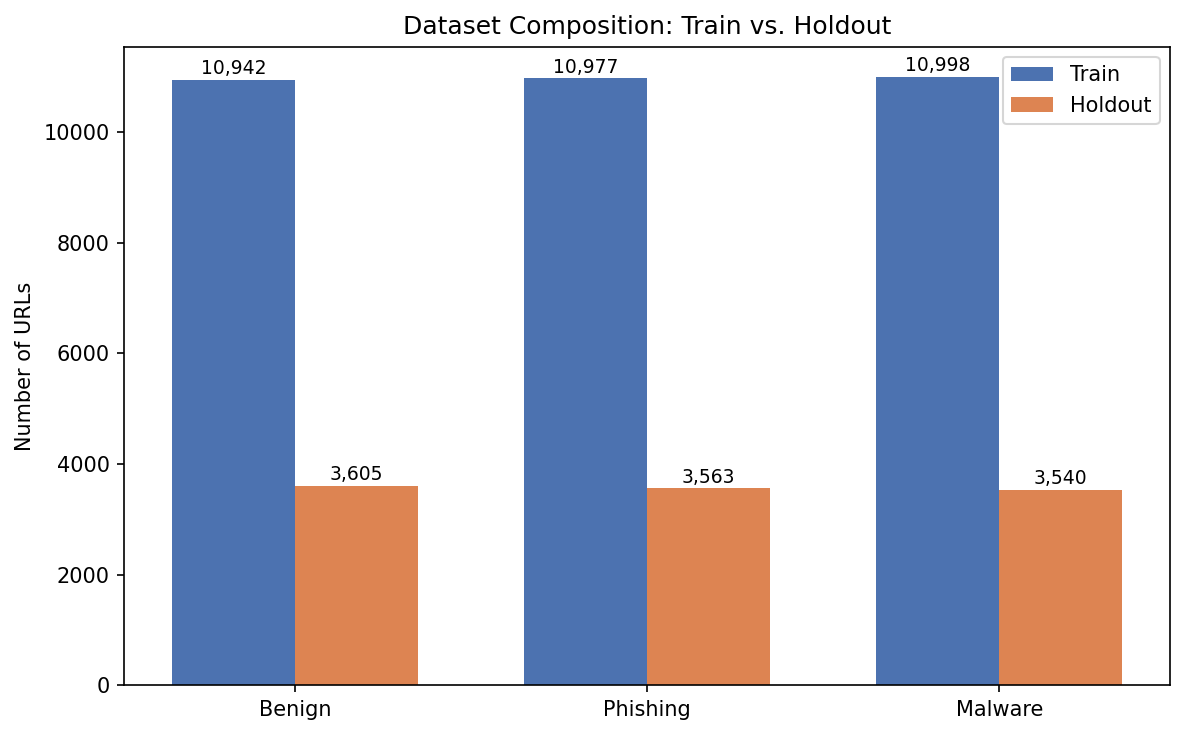

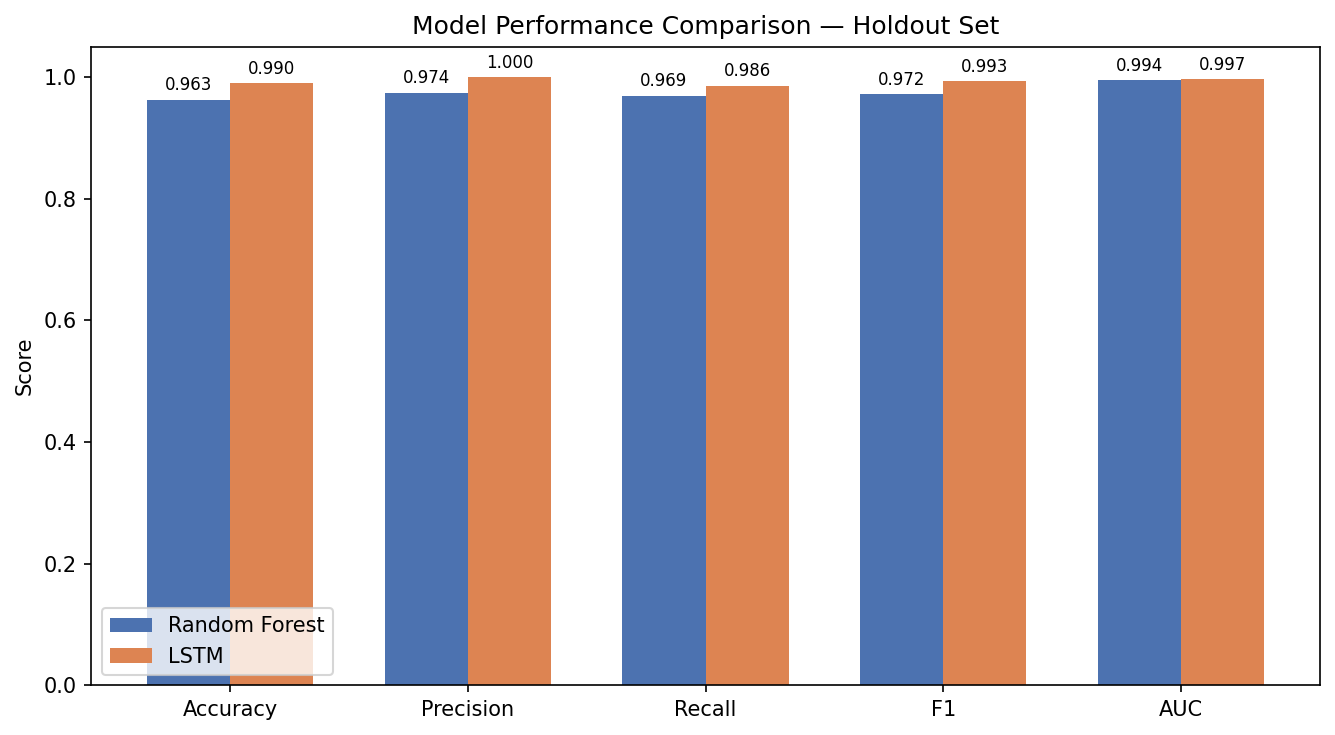

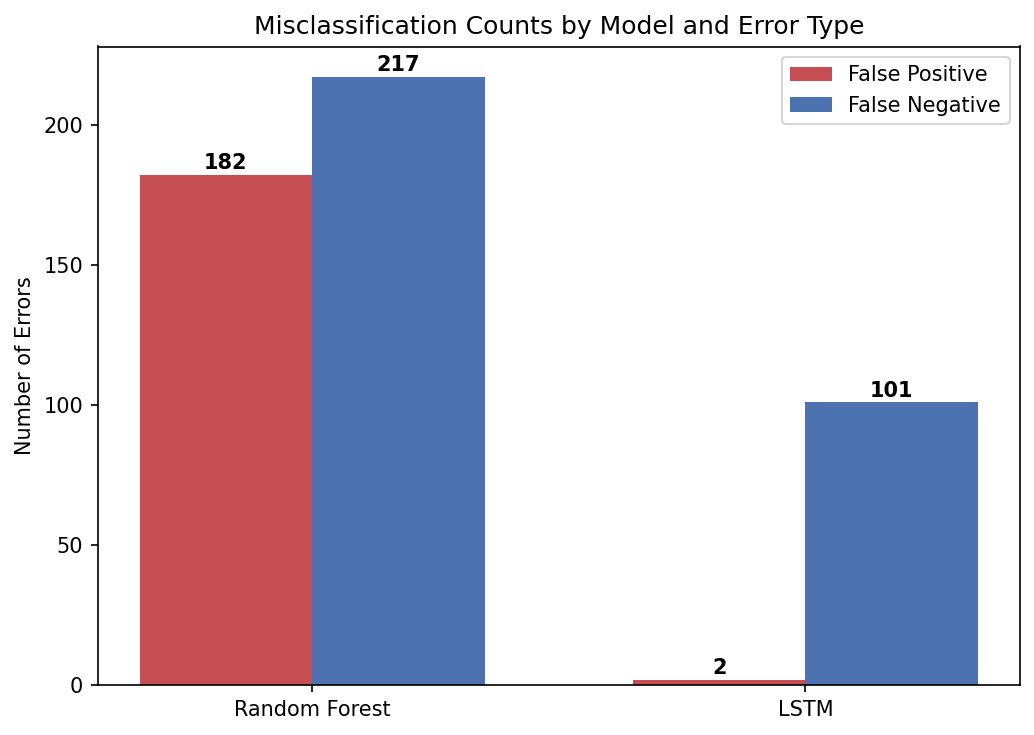

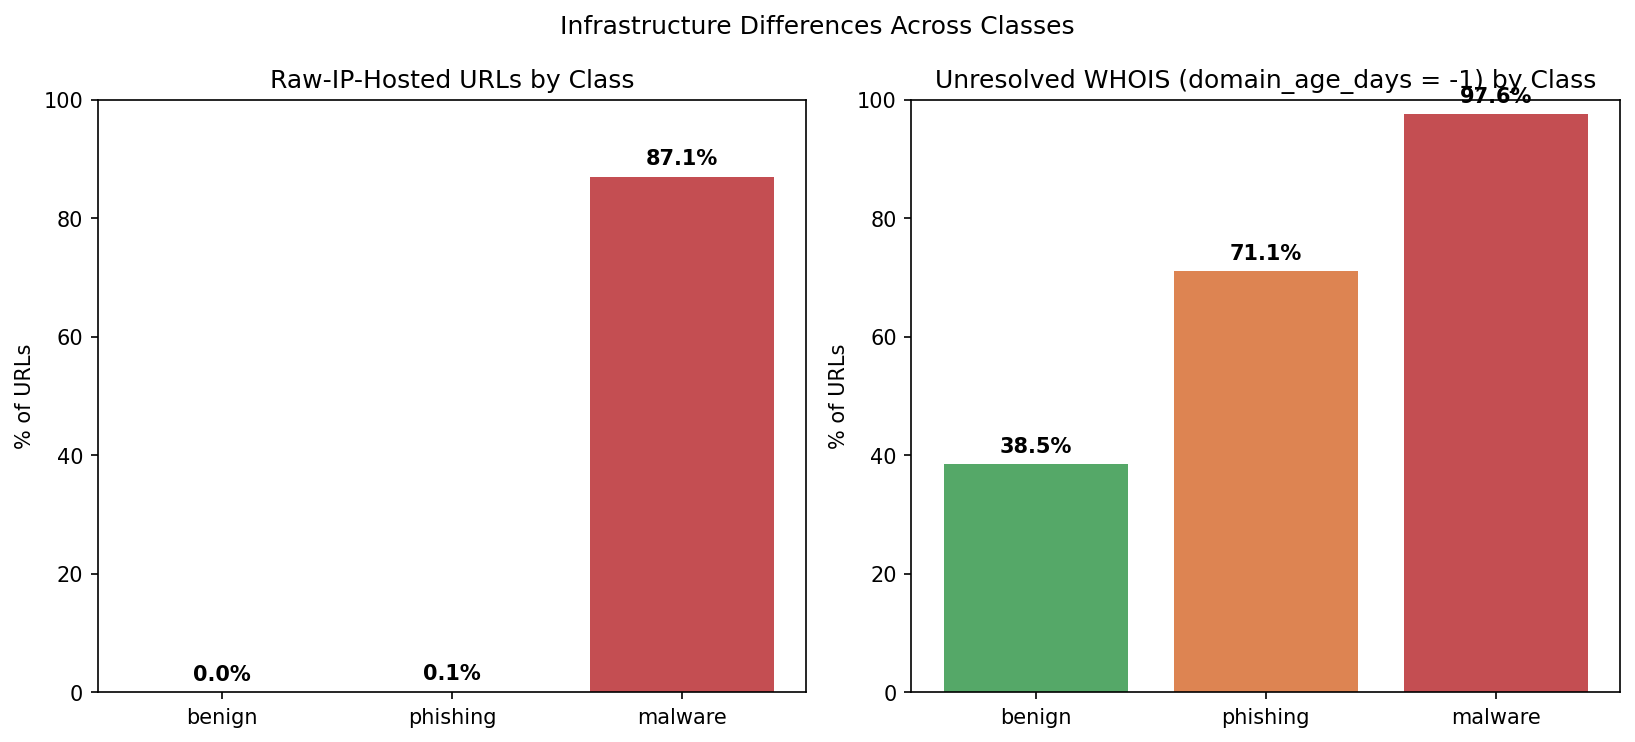

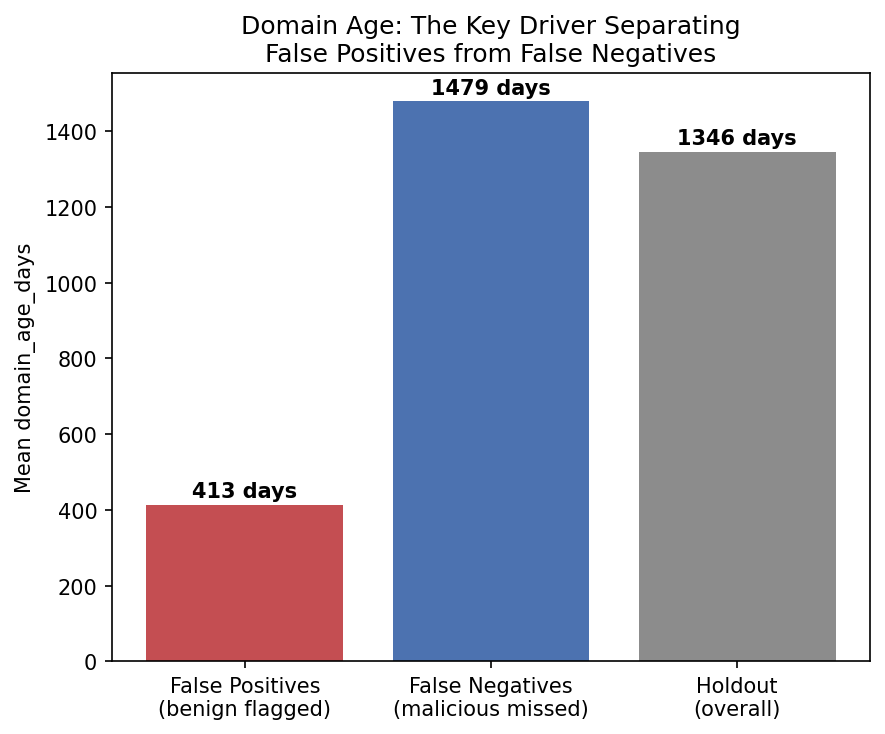

Saved 5 paper-ready figures: fig1 through fig5


In [ ]:
# ============================================================
# STEP 10 — FINAL VISUALIZATIONS FOR THE PAPER
# ============================================================
#
#
#

#   - train_df, holdout_df (Step 2)
#   - full_df (Step 3)
#   - y_holdout, rf_pred, rf_proba (Step 4)
#   - y_holdout_lstm, lstm_pred_tuned, lstm_pred_proba (Step 5)
#   - error_vault_df (Step 6)
#
# PRODUCES (all saved to disk, ready to drop into the paper)
#   - fig1_dataset_composition.png
#   - fig2_model_performance_comparison.png
#   - fig3_error_counts_comparison.png
#   - fig4_malware_infrastructure_findings.png
#   - fig5_domain_age_key_finding.png
#

# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

plt.rcParams["figure.dpi"] = 150

# ------------------------------------------------------------
# FIGURE 1 — Dataset composition: train vs holdout, by class
# ------------------------------------------------------------
train_counts = train_df["label"].value_counts().reindex(["benign", "phishing", "malware"])
holdout_counts = holdout_df["label"].value_counts().reindex(["benign", "phishing", "malware"])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, train_counts.values, width, label="Train", color="#4C72B0")
ax.bar(x + width/2, holdout_counts.values, width, label="Holdout", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(["Benign", "Phishing", "Malware"])
ax.set_ylabel("Number of URLs")
ax.set_title("Dataset Composition: Train vs. Holdout")
ax.legend()
for i, (tr, ho) in enumerate(zip(train_counts.values, holdout_counts.values)):
    ax.text(i - width/2, tr + 100, f"{tr:,}", ha="center", fontsize=9)
    ax.text(i + width/2, ho + 100, f"{ho:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig1_dataset_composition.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 2 — Model performance comparison: RF vs LSTM
# ------------------------------------------------------------
rf_metrics = {
    "Accuracy": accuracy_score(y_holdout, rf_pred),
    "Precision": precision_score(y_holdout, rf_pred),
    "Recall": recall_score(y_holdout, rf_pred),
    "F1": f1_score(y_holdout, rf_pred),
    "AUC": roc_auc_score(y_holdout, rf_proba),
}
lstm_metrics = {
    "Accuracy": accuracy_score(y_holdout_lstm, lstm_pred_tuned),
    "Precision": precision_score(y_holdout_lstm, lstm_pred_tuned),
    "Recall": recall_score(y_holdout_lstm, lstm_pred_tuned),
    "F1": f1_score(y_holdout_lstm, lstm_pred_tuned),
    "AUC": roc_auc_score(y_holdout_lstm, lstm_pred_proba),
}

metric_names = list(rf_metrics.keys())
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metric_names))
width = 0.35
bars1 = ax.bar(x - width/2, [rf_metrics[m] for m in metric_names], width, label="Random Forest", color="#4C72B0")
bars2 = ax.bar(x + width/2, [lstm_metrics[m] for m in metric_names], width, label="LSTM", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison — Holdout Set")
ax.legend()
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
                 f"{b.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig2_model_performance_comparison.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 3 — Error counts comparison: RF vs LSTM, FP vs FN
# ------------------------------------------------------------
error_counts = error_vault_df.groupby(["model", "error_type"]).size().unstack(fill_value=0)
error_counts = error_counts.reindex(["random_forest", "lstm"])

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
fp_vals = error_counts.get("false_positive", pd.Series([0, 0])).values
fn_vals = error_counts.get("false_negative", pd.Series([0, 0])).values
bars1 = ax.bar(x - width/2, fp_vals, width, label="False Positive", color="#C44E52")
bars2 = ax.bar(x + width/2, fn_vals, width, label="False Negative", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(["Random Forest", "LSTM"])
ax.set_ylabel("Number of Errors")
ax.set_title("Misclassification Counts by Model and Error Type")
ax.legend()
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
                 f"{int(b.get_height())}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_error_counts_comparison.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 4 — Malware infrastructure findings: IP-hosting and
# unresolved WHOIS rate by class
# ------------------------------------------------------------
ip_share = full_df.groupby("label")["registrar"].apply(lambda s: (s == "ip_address").mean())
unresolved_share = full_df.groupby("label")["domain_age_days"].apply(lambda s: (s == -1).mean())
labels_order = ["benign", "phishing", "malware"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = ["#55A868", "#DD8452", "#C44E52"]

axes[0].bar(labels_order, [ip_share[l] * 100 for l in labels_order], color=colors)
axes[0].set_ylabel("% of URLs")
axes[0].set_title("Raw-IP-Hosted URLs by Class")
axes[0].set_ylim(0, 100)
for i, l in enumerate(labels_order):
    axes[0].text(i, ip_share[l] * 100 + 2, f"{ip_share[l]*100:.1f}%", ha="center", fontweight="bold")

axes[1].bar(labels_order, [unresolved_share[l] * 100 for l in labels_order], color=colors)
axes[1].set_ylabel("% of URLs")
axes[1].set_title("Unresolved WHOIS (domain_age_days = -1) by Class")
axes[1].set_ylim(0, 100)
for i, l in enumerate(labels_order):
    axes[1].text(i, unresolved_share[l] * 100 + 2, f"{unresolved_share[l]*100:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Infrastructure Differences Across Classes")
plt.tight_layout()
plt.savefig("fig4_malware_infrastructure_findings.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 5 — Key finding: domain_age_days, FP vs FN vs holdout
# (isolated and clean —
# ------------------------------------------------------------
fp_ids = error_vault_df.loc[error_vault_df["error_type"] == "false_positive", "url_id"].astype(str)
fn_ids = error_vault_df.loc[error_vault_df["error_type"] == "false_negative", "url_id"].astype(str)
full_df["url_id"] = full_df["url_id"].astype(str)

fp_age = full_df[full_df["url_id"].isin(fp_ids)]["domain_age_days"].mean()
fn_age = full_df[full_df["url_id"].isin(fn_ids)]["domain_age_days"].mean()
holdout_age = holdout_df["domain_age_days"].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["False Positives\n(benign flagged)", "False Negatives\n(malicious missed)", "Holdout\n(overall)"],
    [fp_age, fn_age, holdout_age],
    color=["#C44E52", "#4C72B0", "#8C8C8C"],
)
ax.set_ylabel("Mean domain_age_days")
ax.set_title("Domain Age: The Key Driver Separating\nFalse Positives from False Negatives")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
             f"{b.get_height():.0f} days", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_domain_age_key_finding.png")
plt.show()

print("Saved 5 paper-ready figures: fig1 through fig5")

#STEP 11: STRATIFIED ERROR ANALYSIS

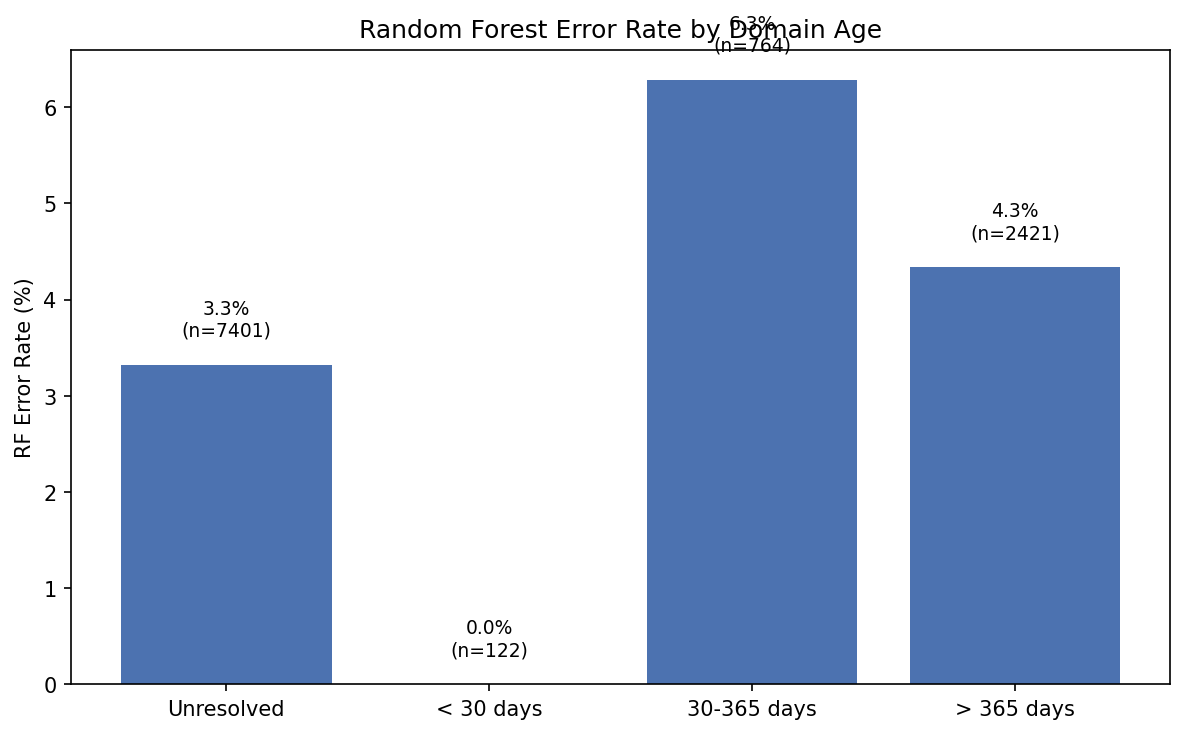

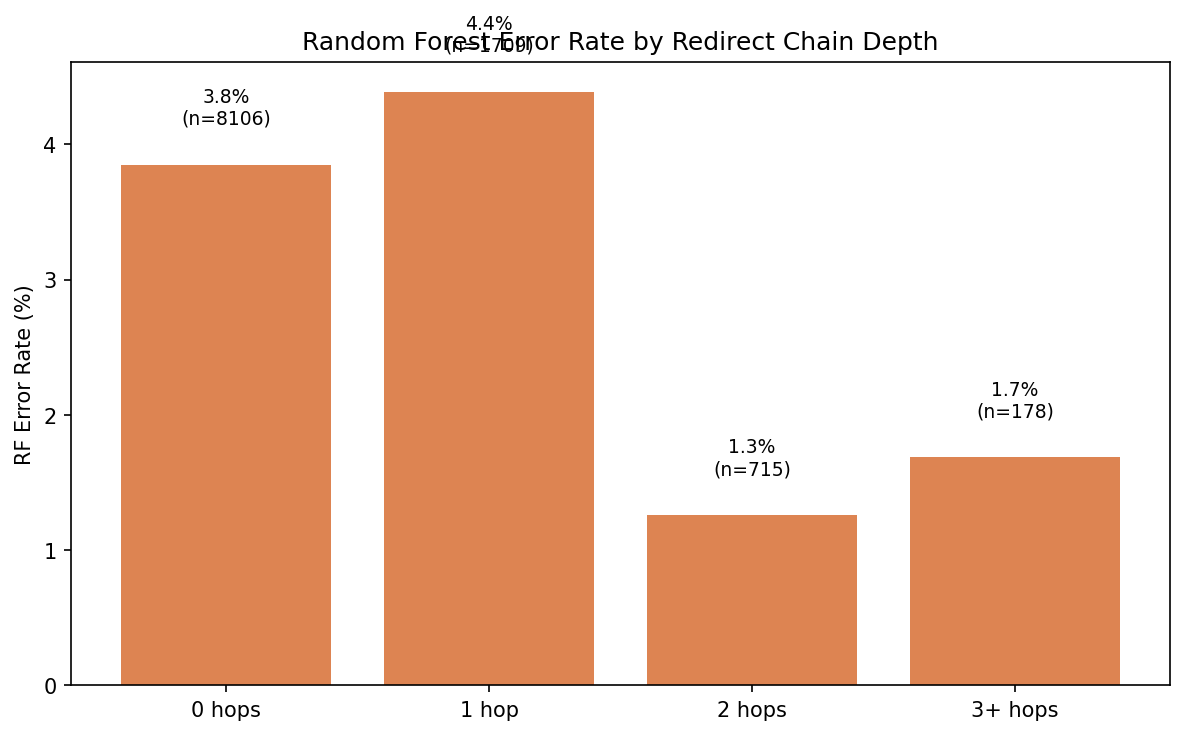

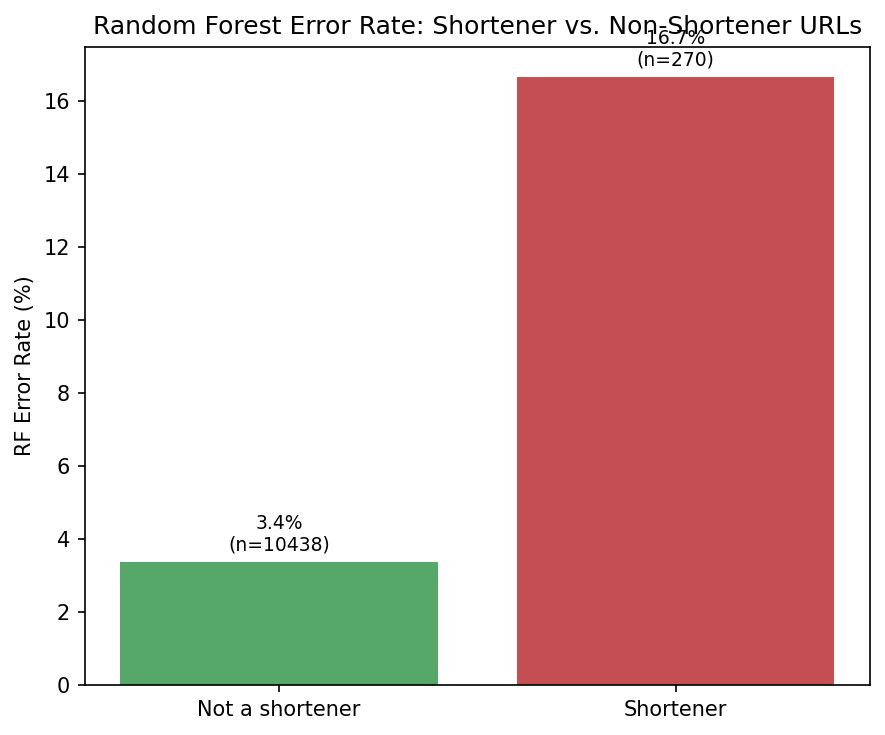

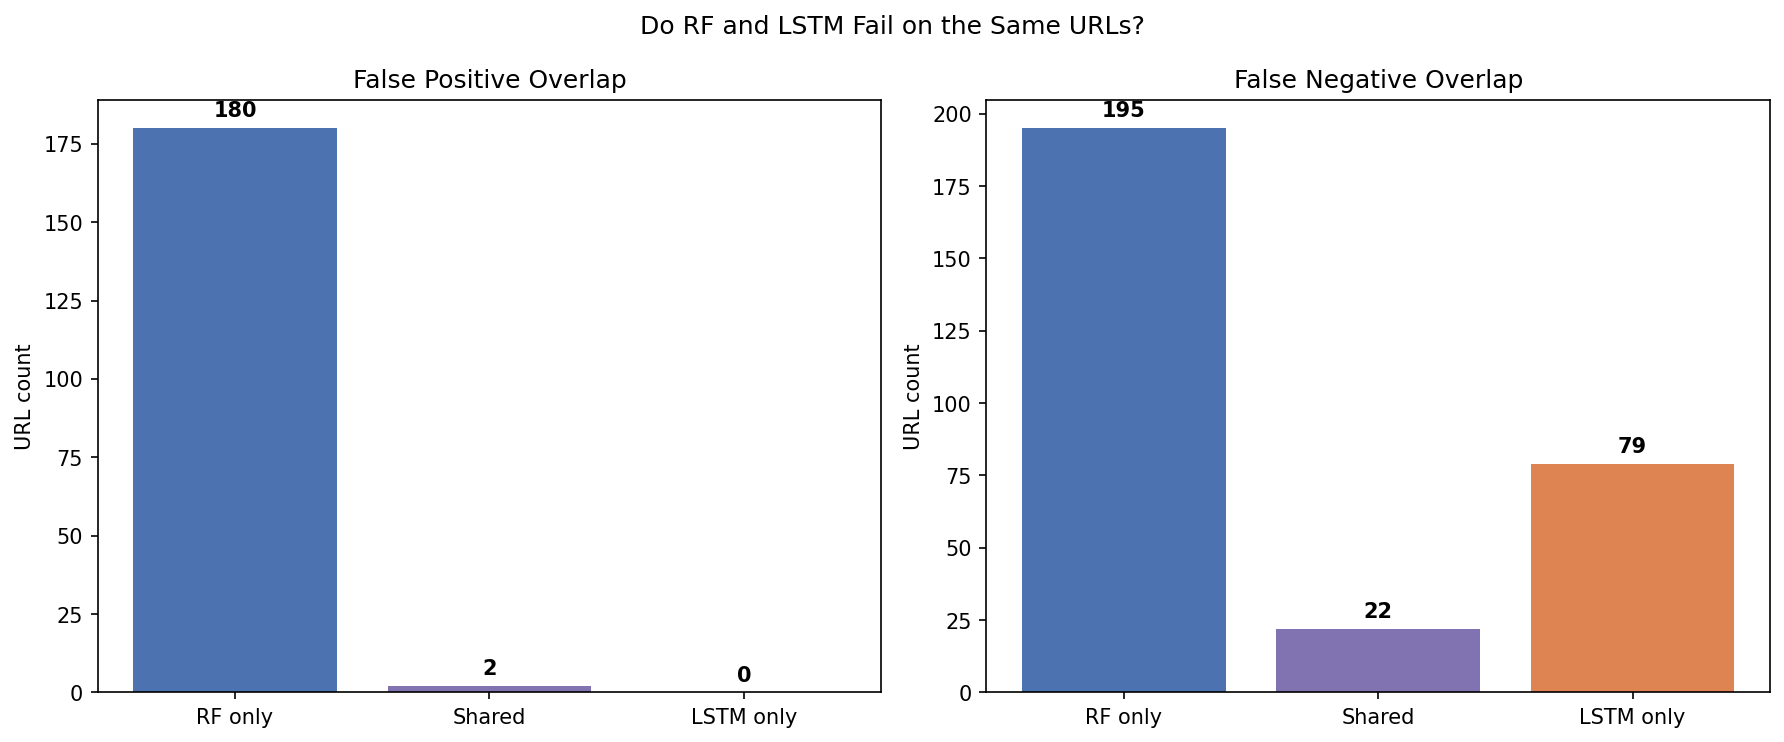

FP overlap — RF only: 180, Shared: 2, LSTM only: 0
FN overlap — RF only: 195, Shared: 22, LSTM only: 79


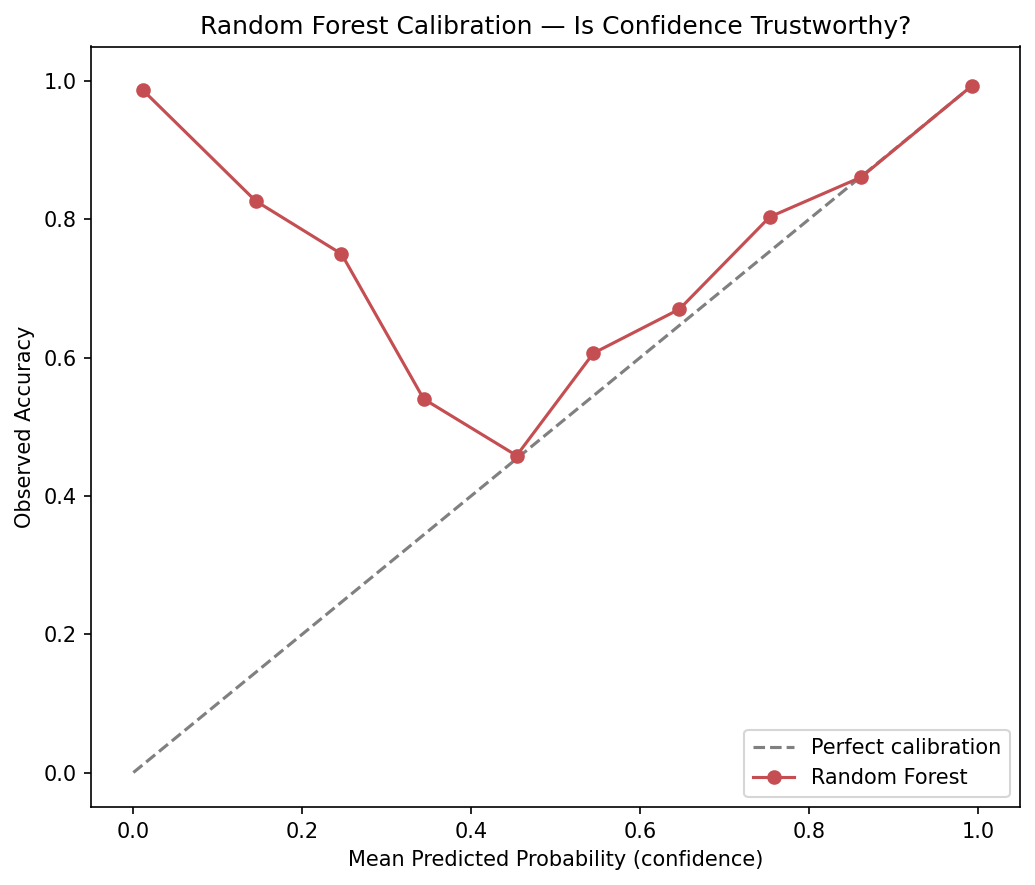


Calibration bins (confidence, accuracy, count):
  confidence=0.011  accuracy=0.987  n=3089
  confidence=0.145  accuracy=0.827  n=202
  confidence=0.246  accuracy=0.750  n=128
  confidence=0.344  accuracy=0.540  n=124
  confidence=0.454  accuracy=0.458  n=96
  confidence=0.545  accuracy=0.606  n=94
  confidence=0.647  accuracy=0.670  n=97
  confidence=0.754  accuracy=0.803  n=173
  confidence=0.862  accuracy=0.861  n=259
  confidence=0.993  accuracy=0.993  n=6446


In [ ]:
# ============================================================
# STEP 11 — STRATIFIED ERROR ANALYSIS
# ============================================================
# PURPOSE
#   SHAP/LIME (Steps 7-8) show which FEATURES drive misclassification.
#   This step measures how ERROR RATE itself changes across the
#   specific evasion behaviors named in the proposal (domain age,
#   redirect chains, URL shorteners) — a more direct test of "does this
#   behavior correlate with failure" than feature importance alone.
#
# REQUIRES (all in memory from Steps 4-6)
#   - full_df_rf, rf_holdout_mask, y_holdout, rf_pred, rf_proba (Step 4)
#   - lstm_combined, lstm_holdout_mask, y_holdout_lstm, lstm_pred_tuned (Step 5)
#   - error_vault_df (Step 6)
#
# PRODUCES
#   - fig6_error_rate_by_domain_age.png
#   - fig7_error_rate_by_redirect_hops.png
#   - fig8_error_rate_by_shortener.png
#   - fig9_rf_lstm_error_overlap.png
#   - fig10_rf_calibration_diagram.png
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150

# ------------------------------------------------------------
# Builds one holdout dataframe with true label, RF prediction, and the
# behavioral/temporal features needed for stratification
# ------------------------------------------------------------
holdout_analysis = full_df_rf.loc[rf_holdout_mask].reset_index(drop=True).copy()
holdout_analysis["y_true"] = np.asarray(y_holdout)
holdout_analysis["rf_pred"] = np.asarray(rf_pred)
holdout_analysis["rf_error"] = (holdout_analysis["y_true"] != holdout_analysis["rf_pred"]).astype(int)

# ------------------------------------------------------------
# FIGURE 6 — Error rate by domain age bucket
# Tests: does models fail more often on newly-registered / unresolved
# domains, or on established ones (e.g. compromised legitimate sites)?
# ------------------------------------------------------------
def age_bucket(days):
    if days == -1:
        return "Unresolved"
    elif days < 30:
        return "< 30 days"
    elif days < 365:
        return "30-365 days"
    else:
        return "> 365 days"

holdout_analysis["age_bucket"] = holdout_analysis["domain_age_days"].apply(age_bucket)
bucket_order = ["Unresolved", "< 30 days", "30-365 days", "> 365 days"]

error_by_age = holdout_analysis.groupby("age_bucket")["rf_error"].agg(["mean", "count"]).reindex(bucket_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bucket_order, error_by_age["mean"] * 100, color="#4C72B0")
ax.set_ylabel("RF Error Rate (%)")
ax.set_title("Random Forest Error Rate by Domain Age")
for b, (rate, n) in zip(bars, zip(error_by_age["mean"], error_by_age["count"])):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{rate*100:.1f}%\n(n={n})", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig6_error_rate_by_domain_age.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 7 — Error rate by redirect hop count
# Tests: does redirect chain depth correlate with error rate?
# ------------------------------------------------------------
def hop_bucket(hops):
    if hops == 0:
        return "0 hops"
    elif hops == 1:
        return "1 hop"
    elif hops == 2:
        return "2 hops"
    else:
        return "3+ hops"

holdout_analysis["hop_bucket"] = holdout_analysis["redirect_hops"].apply(hop_bucket)
hop_order = ["0 hops", "1 hop", "2 hops", "3+ hops"]

error_by_hops = holdout_analysis.groupby("hop_bucket")["rf_error"].agg(["mean", "count"]).reindex(hop_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(hop_order, error_by_hops["mean"] * 100, color="#DD8452")
ax.set_ylabel("RF Error Rate (%)")
ax.set_title("Random Forest Error Rate by Redirect Chain Depth")
for b, (rate, n) in zip(bars, zip(error_by_hops["mean"], error_by_hops["count"])):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{rate*100:.1f}%\n(n={n})", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig7_error_rate_by_redirect_hops.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 8 — Error rate by shortener presence
# Tests: are shortened URLs specifically harder for the model?
# ------------------------------------------------------------
error_by_shortener = holdout_analysis.groupby("is_shortener")["rf_error"].agg(["mean", "count"])
shortener_labels = ["Not a shortener", "Shortener"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(shortener_labels, error_by_shortener["mean"].reindex([0, 1]) * 100, color=["#55A868", "#C44E52"])
for b, idx in zip(bars, [0, 1]):
    if idx in error_by_shortener.index:
        rate = error_by_shortener.loc[idx, "mean"]
        n = error_by_shortener.loc[idx, "count"]
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{rate*100:.1f}%\n(n={n})", ha="center", fontsize=9)
ax.set_ylabel("RF Error Rate (%)")
ax.set_title("Random Forest Error Rate: Shortener vs. Non-Shortener URLs")
plt.tight_layout()
plt.savefig("fig8_error_rate_by_shortener.png")
plt.show()

# ------------------------------------------------------------
# FIGURE 9 — RF vs LSTM error overlap
# Tests: do both models fail on the same URLs (shared blind spot) or
# different URLs (complementary weaknesses)?
# ------------------------------------------------------------
rf_fp_ids = set(error_vault_df.loc[(error_vault_df["model"] == "random_forest") &
                                     (error_vault_df["error_type"] == "false_positive"), "url_id"])
lstm_fp_ids = set(error_vault_df.loc[(error_vault_df["model"] == "lstm") &
                                       (error_vault_df["error_type"] == "false_positive"), "url_id"])
rf_fn_ids = set(error_vault_df.loc[(error_vault_df["model"] == "random_forest") &
                                     (error_vault_df["error_type"] == "false_negative"), "url_id"])
lstm_fn_ids = set(error_vault_df.loc[(error_vault_df["model"] == "lstm") &
                                       (error_vault_df["error_type"] == "false_negative"), "url_id"])

def overlap_counts(set_a, set_b):
    only_a = len(set_a - set_b)
    shared = len(set_a & set_b)
    only_b = len(set_b - set_a)
    return only_a, shared, only_b

fp_only_rf, fp_shared, fp_only_lstm = overlap_counts(rf_fp_ids, lstm_fp_ids)
fn_only_rf, fn_shared, fn_only_lstm = overlap_counts(rf_fn_ids, lstm_fn_ids)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["RF only", "Shared", "LSTM only"]

axes[0].bar(labels, [fp_only_rf, fp_shared, fp_only_lstm], color=["#4C72B0", "#8172B2", "#DD8452"])
axes[0].set_title("False Positive Overlap")
axes[0].set_ylabel("URL count")
for i, v in enumerate([fp_only_rf, fp_shared, fp_only_lstm]):
    axes[0].text(i, v + max(fp_only_rf, fp_shared, fp_only_lstm, 1) * 0.02, str(v), ha="center", fontweight="bold")

axes[1].bar(labels, [fn_only_rf, fn_shared, fn_only_lstm], color=["#4C72B0", "#8172B2", "#DD8452"])
axes[1].set_title("False Negative Overlap")
axes[1].set_ylabel("URL count")
for i, v in enumerate([fn_only_rf, fn_shared, fn_only_lstm]):
    axes[1].text(i, v + max(fn_only_rf, fn_shared, fn_only_lstm, 1) * 0.02, str(v), ha="center", fontweight="bold")

plt.suptitle("Do RF and LSTM Fail on the Same URLs?")
plt.tight_layout()
plt.savefig("fig9_rf_lstm_error_overlap.png")
plt.show()

print(f"FP overlap — RF only: {fp_only_rf}, Shared: {fp_shared}, LSTM only: {fp_only_lstm}")
print(f"FN overlap — RF only: {fn_only_rf}, Shared: {fn_shared}, LSTM only: {fn_only_lstm}")

# ------------------------------------------------------------
# FIGURE 10 — RF calibration / reliability diagram
# Tests: when the RF is wrong, is it confidently wrong (dangerous —
# hard to catch downstream) or uncertainly wrong (safer — a human
# reviewer or secondary check would likely catch it)?
# ------------------------------------------------------------
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_indices = np.digitize(rf_proba, bin_edges[1:-1])

bin_confidence = []
bin_accuracy = []
bin_counts = []
for b in range(n_bins):
    mask = bin_indices == b
    if mask.sum() == 0:
        continue
    bin_confidence.append(rf_proba[mask].mean())
    bin_accuracy.append((np.asarray(y_holdout)[mask] == rf_pred[mask]).mean())
    bin_counts.append(mask.sum())

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(bin_confidence, bin_accuracy, marker="o", color="#C44E52", label="Random Forest")
ax.set_xlabel("Mean Predicted Probability (confidence)")
ax.set_ylabel("Observed Accuracy")
ax.set_title("Random Forest Calibration — Is Confidence Trustworthy?")
ax.legend()
plt.tight_layout()
plt.savefig("fig10_rf_calibration_diagram.png")
plt.show()

print("\nCalibration bins (confidence, accuracy, count):")
for c, a, n in zip(bin_confidence, bin_accuracy, bin_counts):
    print(f"  confidence={c:.3f}  accuracy={a:.3f}  n={n}")